# Feedforward Neural Network - Experiments

Notebook ini berisi eksperimen-eksperimen sesuai spesifikasi Tugas Besar 1 IF3270 Pembelajaran Mesin.
1. 13523124 - Muhammad Raihaan Perdana
2. 13523136 - Danendra Shafi Athallah
3. 13523155 - M. Abizzar Gamadrian

## 1. Setup dan Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

# Import modules
from src.models.ffnn import FFNN
from src.utils.preprocessing import DataPreprocessor
from src.utils.metrics import accuracy, precision, recall, f1_score, confusion_matrix
from src.utils.plotting import plot_training_history, plot_weight_distribution, plot_gradient_distribution
from src.utils.io import save_training_history, load_training_history

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Library imported successfully!")

c:\Users\Raihaan\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Library imported successfully!


## 2. Preprocessing Dataset

In [2]:
# Path ke dataset
data_path = '../data/datasetml_2026.csv'

# Preprocessing
preprocessor = DataPreprocessor(data_path)
preprocessor.load_data()
preprocessor.explore_data()
preprocessor.visualize_data(save_path='../data/eda_visualization.png')

# Preprocess dan split data
X_train, X_val, X_test, y_train, y_val, y_test = preprocessor.preprocess_data(
    test_size=0.2,
    val_size=0.2,
    random_state=42
)

# Dapatkan info data
info = preprocessor.get_data_info()
print(f"\nInformasi Dataset:")
print(f"  Jumlah fitur: {info['n_features']}")
print(f"  Jumlah kelas: {info['n_classes']}")
print(f"  Train samples: {info['n_train_samples']}")
print(f"  Val samples: {info['n_val_samples']}")
print(f"  Test samples: {info['n_test_samples']}")

memuat dataset...
dataset berhasil dimuat! shape: (10000, 12)

exploratory data analysis

1. info dataset:
   - total baris: 10000
   - total kolom: 12

2. tipe kolom:
cgpa                        float64
backlogs                      int64
college_tier                 object
country                      object
university_ranking_band      object
internship_count              int64
aptitude_score              float64
communication_score         float64
specialization               object
industry                     object
internship_quality_score    float64
placement_status             object
dtype: object

3. nilai yang hilang:
   tidak ada nilai yang hilang

4. ringkasan statistik untuk kolom numerik:
               cgpa      backlogs  internship_count  aptitude_score  \
count  10000.000000  10000.000000       10000.00000    10000.000000   
mean       6.998290      1.248100           1.49930       69.877531   
std        0.802606      1.149904           1.20289       14.700532   
min

## 3. Eksperimen 1: Pengaruh Depth dan Width

Menganalisis pengaruh banyak layer (depth) dan banyak neuron per layer (width)

In [3]:
# Konfigurasi eksperimen
n_features = info['n_features']
n_classes = info['n_classes']

# 3 variasi width (depth tetap = 3 layer)
width_configs = [
    {'name': 'Narrow (8 neurons)', 'layer_sizes': [n_features, 8, 8, n_classes]},
    {'name': 'Medium (16 neurons)', 'layer_sizes': [n_features, 16, 16, n_classes]},
    {'name': 'Wide (32 neurons)', 'layer_sizes': [n_features, 32, 32, n_classes]}
]

width_results = {}
epochs = 50

for config in width_configs:
    print(f"\n{'='*60}")
    print(f"Testing: {config['name']}")
    print(f"{'='*60}")
    
    model = FFNN(
        layer_sizes=config['layer_sizes'],
        activations=['relu', 'relu', 'softmax'],
        loss_function='categorical_cross_entropy',
        initializer='uniform',
        learning_rate=0.01
    )
    
    history = model.train(
        X_train, y_train, X_val, y_val,
        batch_size=32,
        learning_rate=0.01,
        epochs=epochs,
        verbose=1
    )
    
    # Evaluasi
    y_pred = model.predict(X_test)
    acc = accuracy(y_test, y_pred)
    
    width_results[config['name']] = {
        'model': model,
        'history': history,
        'accuracy': acc,
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1]
    }
    
    print(f"Test Accuracy: {acc:.4f}")


Testing: Narrow (8 neurons)
Epoch 1/50 - Train Loss: 0.6664 - Val Loss: 0.6347
Epoch 2/50 - Train Loss: 0.6236 - Val Loss: 0.6115
Epoch 3/50 - Train Loss: 0.6026 - Val Loss: 0.5957
Epoch 4/50 - Train Loss: 0.5860 - Val Loss: 0.5837
  >> Reducing LR: 0.005000
Epoch 5/50 - Train Loss: 0.5736 - Val Loss: 0.5746
Epoch 6/50 - Train Loss: 0.5650 - Val Loss: 0.5707
Epoch 7/50 - Train Loss: 0.5603 - Val Loss: 0.5670
Epoch 8/50 - Train Loss: 0.5567 - Val Loss: 0.5636
Epoch 9/50 - Train Loss: 0.5525 - Val Loss: 0.5607
  >> Reducing LR: 0.002500
Epoch 10/50 - Train Loss: 0.5489 - Val Loss: 0.5578
Epoch 11/50 - Train Loss: 0.5459 - Val Loss: 0.5564
Epoch 12/50 - Train Loss: 0.5448 - Val Loss: 0.5551
Epoch 13/50 - Train Loss: 0.5429 - Val Loss: 0.5538
Epoch 14/50 - Train Loss: 0.5416 - Val Loss: 0.5526
  >> Reducing LR: 0.001250
Epoch 15/50 - Train Loss: 0.5397 - Val Loss: 0.5517
Epoch 16/50 - Train Loss: 0.5393 - Val Loss: 0.5510
Epoch 17/50 - Train Loss: 0.5387 - Val Loss: 0.5505
Epoch 18/50 - T

In [4]:
# 3 variasi depth (width tetap = 16 neurons)
depth_configs = [
    {'name': 'Shallow (2 hidden)', 'layer_sizes': [n_features, 16, 16, n_classes]},
    {'name': 'Medium (3 hidden)', 'layer_sizes': [n_features, 16, 16, 16, n_classes]},
    {'name': 'Deep (4 hidden)', 'layer_sizes': [n_features, 16, 16, 16, 16, n_classes]}
]

depth_results = {}

for config in depth_configs:
    print(f"\n{'='*60}")
    print(f"Testing: {config['name']}")
    print(f"{'='*60}")
    
    activations = ['relu'] * (len(config['layer_sizes']) - 2) + ['softmax']
    
    model = FFNN(
        layer_sizes=config['layer_sizes'],
        activations=activations,
        loss_function='categorical_cross_entropy',
        initializer='uniform',
        learning_rate=0.01
    )
    
    history = model.train(
        X_train, y_train, X_val, y_val,
        batch_size=32,
        learning_rate=0.01,
        epochs=epochs,
        verbose=1
    )
    
    # Evaluasi
    y_pred = model.predict(X_test)
    acc = accuracy(y_test, y_pred)
    
    depth_results[config['name']] = {
        'model': model,
        'history': history,
        'accuracy': acc,
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1]
    }
    
    print(f"Test Accuracy: {acc:.4f}")


Testing: Shallow (2 hidden)
Epoch 1/50 - Train Loss: 0.6894 - Val Loss: 0.6421
Epoch 2/50 - Train Loss: 0.6199 - Val Loss: 0.6038
Epoch 3/50 - Train Loss: 0.5887 - Val Loss: 0.5800
Epoch 4/50 - Train Loss: 0.5668 - Val Loss: 0.5657
  >> Reducing LR: 0.005000
Epoch 5/50 - Train Loss: 0.5520 - Val Loss: 0.5539
Epoch 6/50 - Train Loss: 0.5426 - Val Loss: 0.5502
Epoch 7/50 - Train Loss: 0.5370 - Val Loss: 0.5470
Epoch 8/50 - Train Loss: 0.5337 - Val Loss: 0.5442
Epoch 9/50 - Train Loss: 0.5310 - Val Loss: 0.5422
  >> Reducing LR: 0.002500
Epoch 10/50 - Train Loss: 0.5273 - Val Loss: 0.5399
Epoch 11/50 - Train Loss: 0.5252 - Val Loss: 0.5388
Epoch 12/50 - Train Loss: 0.5240 - Val Loss: 0.5380
Epoch 13/50 - Train Loss: 0.5228 - Val Loss: 0.5371
Epoch 14/50 - Train Loss: 0.5214 - Val Loss: 0.5364
  >> Reducing LR: 0.001250
Epoch 15/50 - Train Loss: 0.5204 - Val Loss: 0.5358
Epoch 16/50 - Train Loss: 0.5196 - Val Loss: 0.5356
Epoch 17/50 - Train Loss: 0.5196 - Val Loss: 0.5352
Epoch 18/50 - T

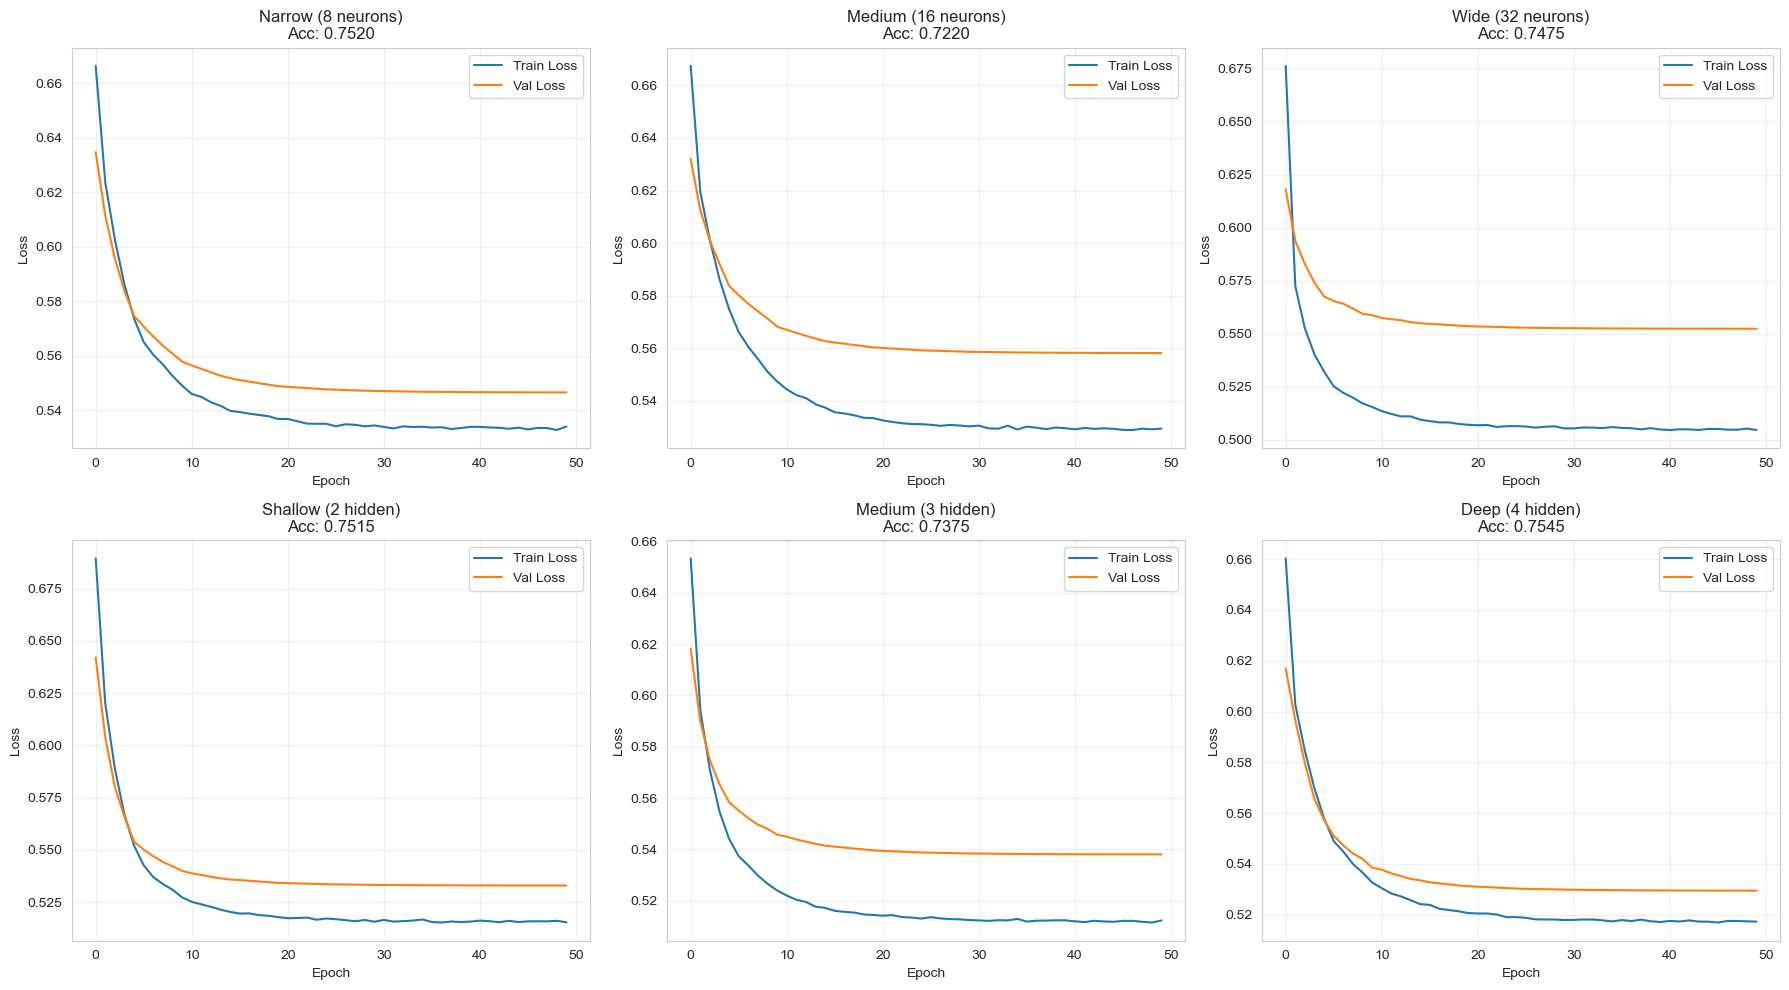


Hasil Eksperimen 1 (Depth & Width):

Width Variations:
  Narrow (8 neurons): Acc=0.7520, Train Loss=0.5340, Val Loss=0.5465
  Medium (16 neurons): Acc=0.7220, Train Loss=0.5294, Val Loss=0.5581
  Wide (32 neurons): Acc=0.7475, Train Loss=0.5046, Val Loss=0.5523

Depth Variations:
  Shallow (2 hidden): Acc=0.7515, Train Loss=0.5154, Val Loss=0.5330
  Medium (3 hidden): Acc=0.7375, Train Loss=0.5123, Val Loss=0.5381
  Deep (4 hidden): Acc=0.7545, Train Loss=0.5173, Val Loss=0.5295


In [5]:
# Plot perbandingan width
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Width comparison - Training Loss
for i, (name, result) in enumerate(width_results.items()):
    axes[0, i].plot(result['history']['train_loss'], label='Train Loss')
    axes[0, i].plot(result['history']['val_loss'], label='Val Loss')
    axes[0, i].set_title(f'{name}\nAcc: {result["accuracy"]:.4f}')
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].legend()
    axes[0, i].grid(True, alpha=0.3)

# Depth comparison - Training Loss
for i, (name, result) in enumerate(depth_results.items()):
    axes[1, i].plot(result['history']['train_loss'], label='Train Loss')
    axes[1, i].plot(result['history']['val_loss'], label='Val Loss')
    axes[1, i].set_title(f'{name}\nAcc: {result["accuracy"]:.4f}')
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylabel('Loss')
    axes[1, i].legend()
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/experiment1_depth_width.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nHasil Eksperimen 1 (Depth & Width):")
print("\nWidth Variations:")
for name, result in width_results.items():
    print(f"  {name}: Acc={result['accuracy']:.4f}, Train Loss={result['final_train_loss']:.4f}, Val Loss={result['final_val_loss']:.4f}")

print("\nDepth Variations:")
for name, result in depth_results.items():
    print(f"  {name}: Acc={result['accuracy']:.4f}, Train Loss={result['final_train_loss']:.4f}, Val Loss={result['final_val_loss']:.4f}")

## 4. Eksperimen 2: Pengaruh Fungsi Aktivasi

Menganalisis pengaruh berbagai fungsi aktivasi pada hidden layer

In [6]:
# Base arsitektur
base_layer_sizes = [n_features, 32, 16, n_classes]  # 3 layer

# Fungsi aktivasi untuk diuji (kecuali softmax untuk output)
activations_to_test = ['linear', 'relu', 'sigmoid', 'tanh']

activation_results = {}

for activation in activations_to_test:
    print(f"\n{'='*60}")
    print(f"Testing: {activation.upper()} activation")
    print(f"{'='*60}")
    
    model = FFNN(
        layer_sizes=base_layer_sizes,
        activations=[activation, activation, 'softmax'],
        loss_function='categorical_cross_entropy',
        initializer='uniform',
        learning_rate=0.01
    )
    
    history = model.train(
        X_train, y_train, X_val, y_val,
        batch_size=32,
        learning_rate=0.01,
        epochs=epochs,
        verbose=1
    )
    
    # Evaluasi
    y_pred = model.predict(X_test)
    acc = accuracy(y_test, y_pred)
    
    activation_results[activation] = {
        'model': model,
        'history': history,
        'accuracy': acc,
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1]
    }
    
    print(f"Test Accuracy: {acc:.4f}")


Testing: LINEAR activation
Epoch 1/50 - Train Loss: 0.5782 - Val Loss: 0.5193
Epoch 2/50 - Train Loss: 0.4981 - Val Loss: 0.5189
Epoch 3/50 - Train Loss: 0.4948 - Val Loss: 0.5147
Epoch 4/50 - Train Loss: 0.4927 - Val Loss: 0.5083
  >> Reducing LR: 0.005000
Epoch 5/50 - Train Loss: 0.4921 - Val Loss: 0.5127
Epoch 6/50 - Train Loss: 0.4892 - Val Loss: 0.5073
Epoch 7/50 - Train Loss: 0.4881 - Val Loss: 0.5058
Epoch 8/50 - Train Loss: 0.4883 - Val Loss: 0.5077
Epoch 9/50 - Train Loss: 0.4876 - Val Loss: 0.5092
  >> Reducing LR: 0.002500
Epoch 10/50 - Train Loss: 0.4885 - Val Loss: 0.5080
Epoch 11/50 - Train Loss: 0.4863 - Val Loss: 0.5064
Epoch 12/50 - Train Loss: 0.4864 - Val Loss: 0.5063
Epoch 13/50 - Train Loss: 0.4862 - Val Loss: 0.5055
Epoch 14/50 - Train Loss: 0.4866 - Val Loss: 0.5056
  >> Reducing LR: 0.001250
Epoch 15/50 - Train Loss: 0.4858 - Val Loss: 0.5077
Epoch 16/50 - Train Loss: 0.4858 - Val Loss: 0.5071
Epoch 17/50 - Train Loss: 0.4858 - Val Loss: 0.5058
Epoch 18/50 - Tr

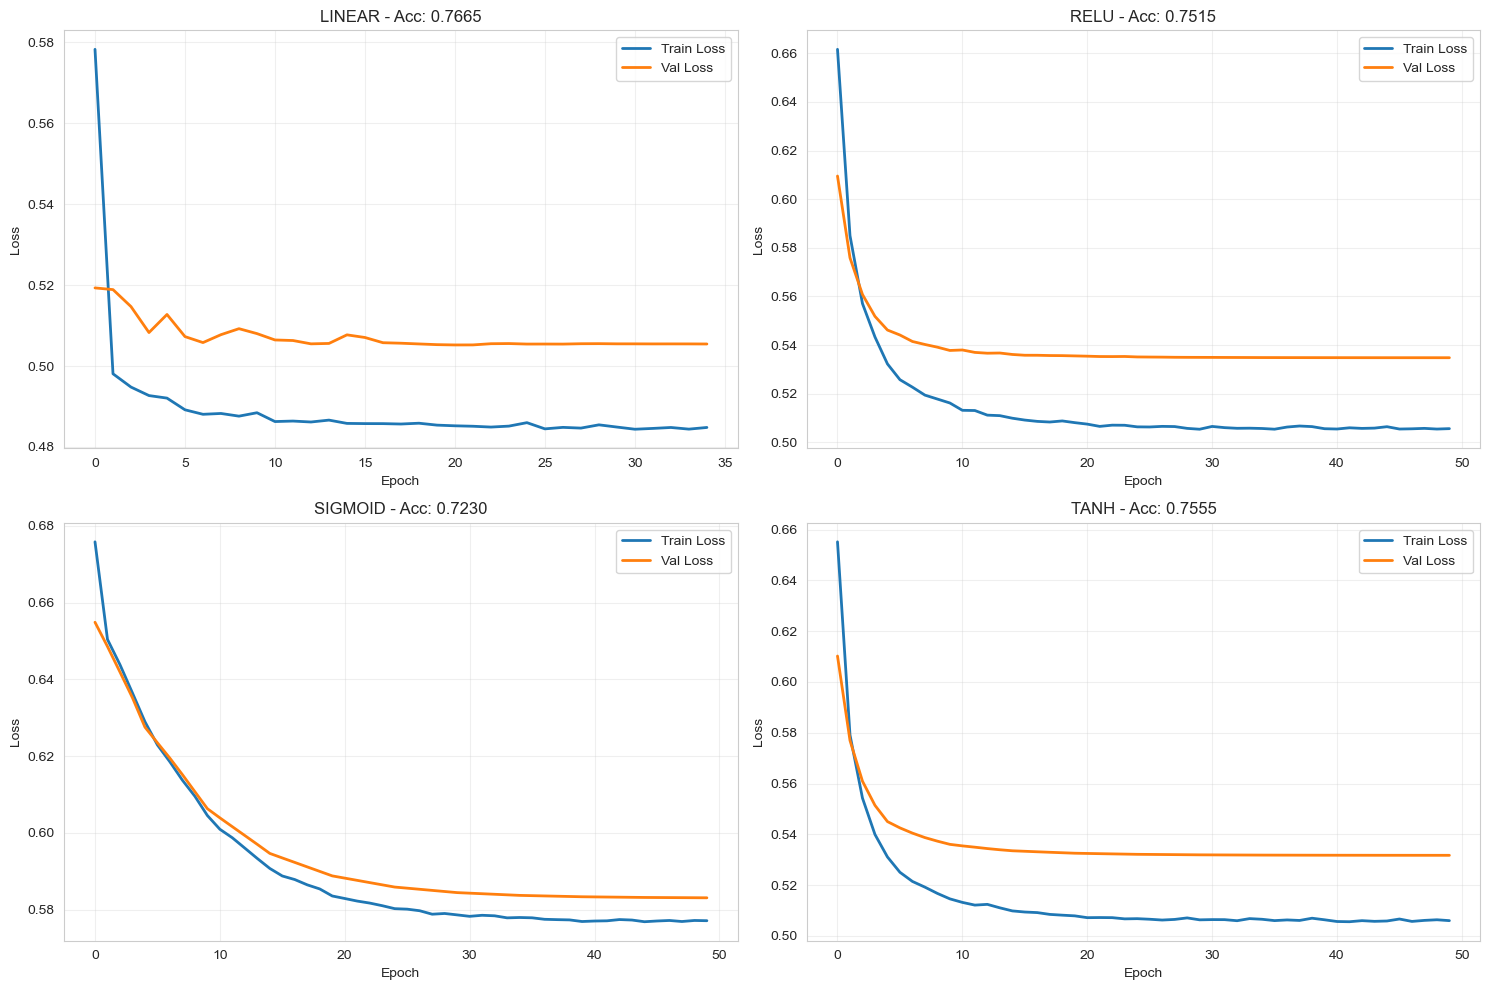

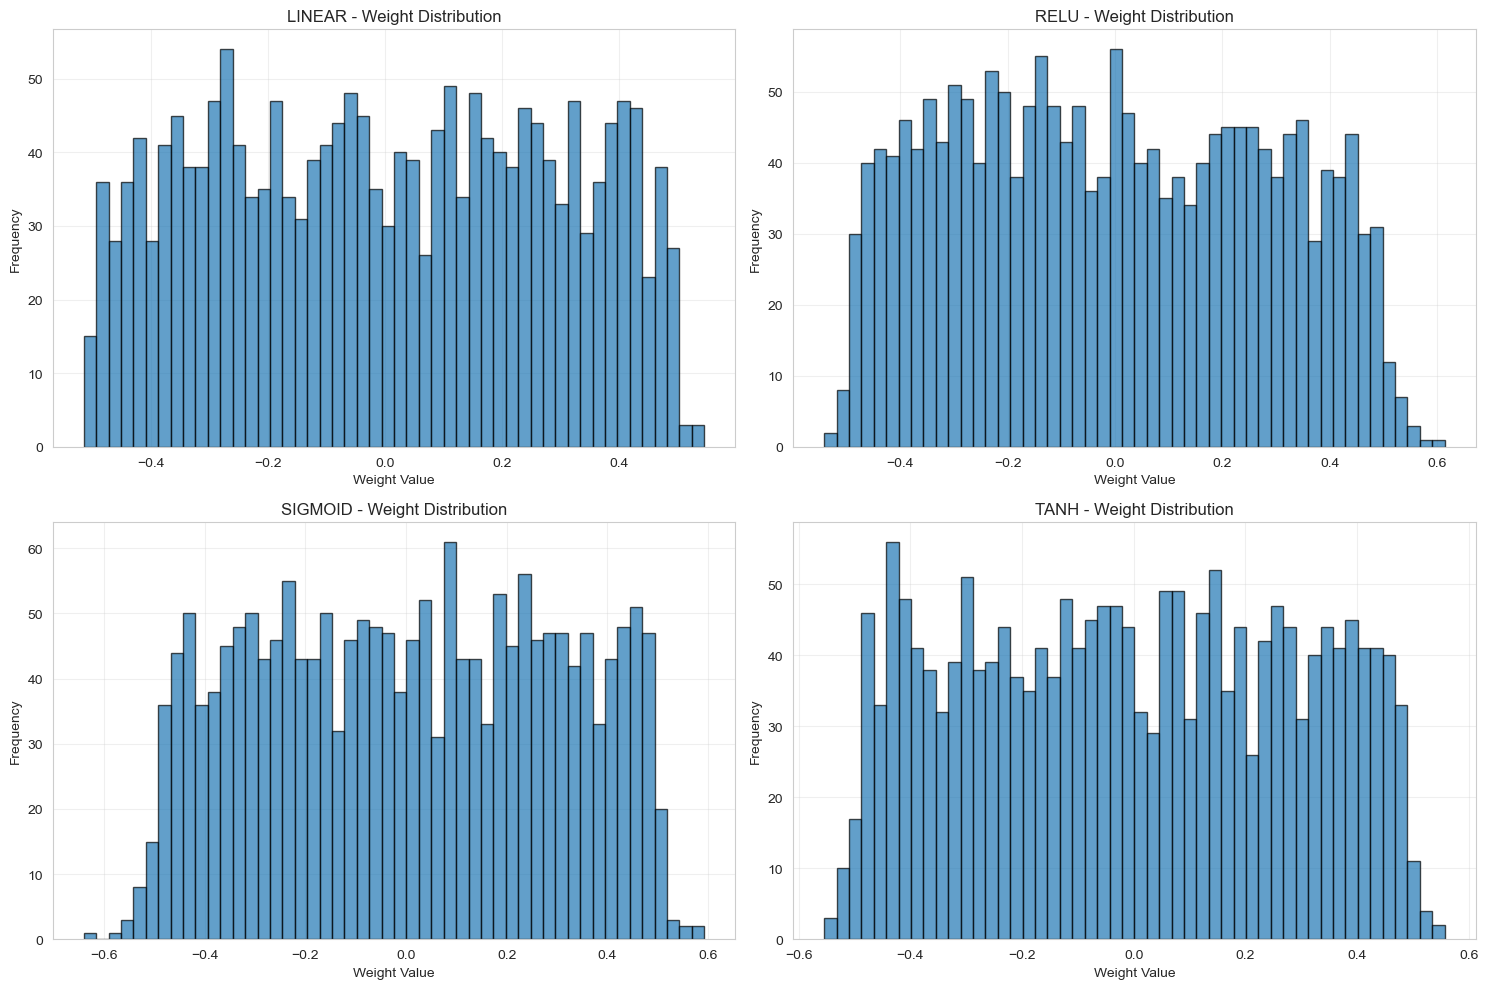


Hasil Eksperimen 2 (Fungsi Aktivasi):
  linear: Acc=0.7665, Train Loss=0.4848, Val Loss=0.5054
  relu: Acc=0.7515, Train Loss=0.5056, Val Loss=0.5348
  sigmoid: Acc=0.7230, Train Loss=0.5772, Val Loss=0.5831
  tanh: Acc=0.7555, Train Loss=0.5060, Val Loss=0.5317


In [7]:
# Plot perbandingan aktivasi
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (activation, result) in enumerate(activation_results.items()):
    axes[i].plot(result['history']['train_loss'], label='Train Loss', linewidth=2)
    axes[i].plot(result['history']['val_loss'], label='Val Loss', linewidth=2)
    axes[i].set_title(f'{activation.upper()} - Acc: {result["accuracy"]:.4f}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/experiment2_activations.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot distribusi bobot untuk beberapa aktivasi
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (activation, result) in enumerate(activation_results.items()):
    model = result['model']
    weights_flat = np.concatenate([w.flatten() for w in model.weights])
    axes[i].hist(weights_flat, bins=50, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{activation.upper()} - Weight Distribution')
    axes[i].set_xlabel('Weight Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/experiment2_weight_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nHasil Eksperimen 2 (Fungsi Aktivasi):")
for activation, result in activation_results.items():
    print(f"  {activation}: Acc={result['accuracy']:.4f}, Train Loss={result['final_train_loss']:.4f}, Val Loss={result['final_val_loss']:.4f}")

## 5. Eksperimen 3: Pengaruh Learning Rate

Menganalisis pengaruh learning rate terhadap training

In [8]:
# Konfigurasi learning rates
learning_rates = [0.001, 0.01, 0.1]

lr_results = {}

for lr in learning_rates:
    print(f"\n{'='*60}")
    print(f"Testing: Learning Rate = {lr}")
    print(f"{'='*60}")
    
    model = FFNN(
        layer_sizes=[n_features, 32, 16, n_classes],
        activations=['relu', 'relu', 'softmax'],
        loss_function='categorical_cross_entropy',
        initializer='uniform',
        learning_rate=lr
    )
    
    history = model.train(
        X_train, y_train, X_val, y_val,
        batch_size=32,
        learning_rate=lr,
        epochs=epochs,
        verbose=1
    )
    
    # Evaluasi
    y_pred = model.predict(X_test)
    acc = accuracy(y_test, y_pred)
    
    lr_results[lr] = {
        'model': model,
        'history': history,
        'accuracy': acc,
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1]
    }
    
    print(f"Test Accuracy: {acc:.4f}")


Testing: Learning Rate = 0.001
Epoch 1/50 - Train Loss: 1.0800 - Val Loss: 0.8626
Epoch 2/50 - Train Loss: 0.8073 - Val Loss: 0.7691
Epoch 3/50 - Train Loss: 0.7398 - Val Loss: 0.7198
Epoch 4/50 - Train Loss: 0.6988 - Val Loss: 0.6880
  >> Reducing LR: 0.000500
Epoch 5/50 - Train Loss: 0.6716 - Val Loss: 0.6663
Epoch 6/50 - Train Loss: 0.6550 - Val Loss: 0.6577
Epoch 7/50 - Train Loss: 0.6463 - Val Loss: 0.6502
Epoch 8/50 - Train Loss: 0.6395 - Val Loss: 0.6438
Epoch 9/50 - Train Loss: 0.6329 - Val Loss: 0.6381
  >> Reducing LR: 0.000250
Epoch 10/50 - Train Loss: 0.6273 - Val Loss: 0.6330
Epoch 11/50 - Train Loss: 0.6232 - Val Loss: 0.6307
Epoch 12/50 - Train Loss: 0.6202 - Val Loss: 0.6285
Epoch 13/50 - Train Loss: 0.6185 - Val Loss: 0.6264
Epoch 14/50 - Train Loss: 0.6162 - Val Loss: 0.6245
  >> Reducing LR: 0.000125
Epoch 15/50 - Train Loss: 0.6134 - Val Loss: 0.6226
Epoch 16/50 - Train Loss: 0.6120 - Val Loss: 0.6217
Epoch 17/50 - Train Loss: 0.6111 - Val Loss: 0.6208
Epoch 18/50 

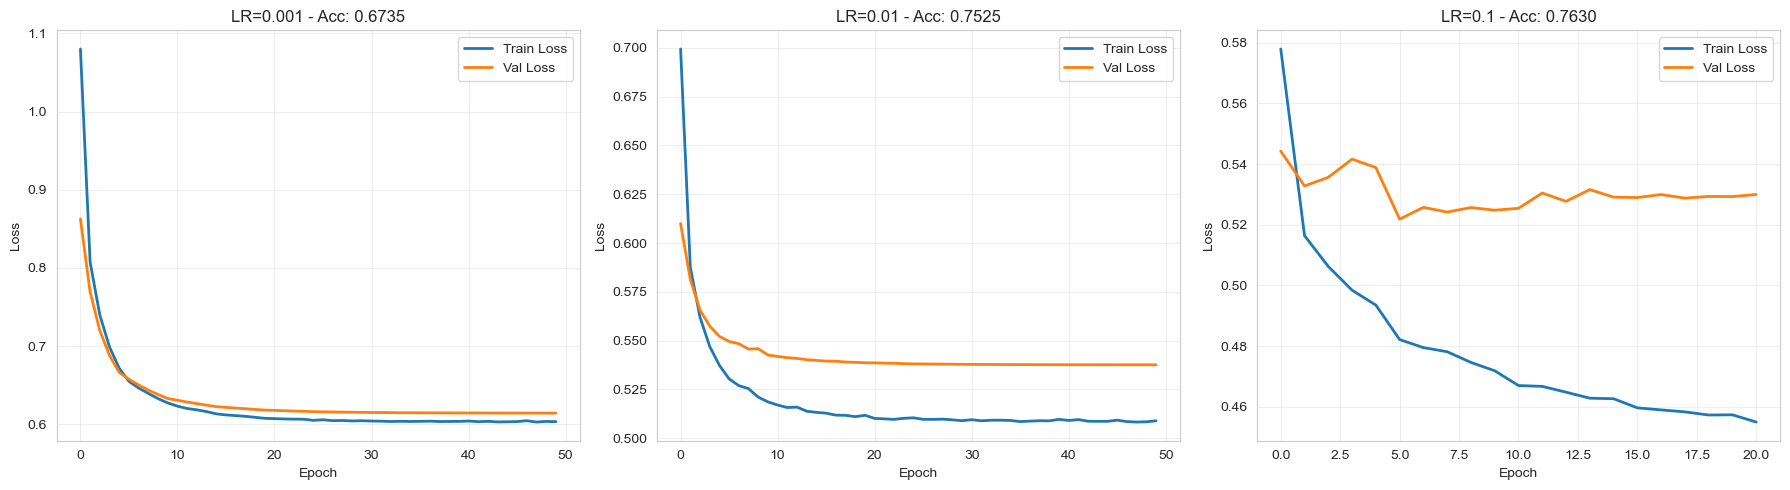

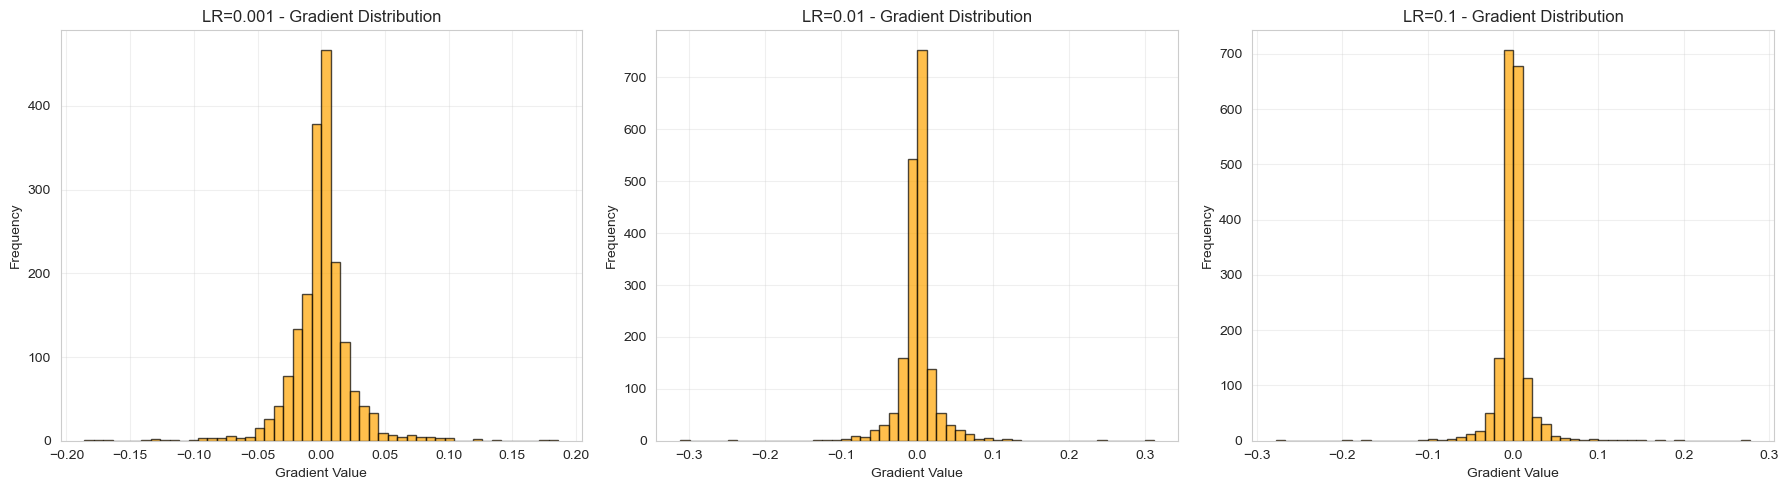


Hasil Eksperimen 3 (Learning Rate):
  LR=0.001: Acc=0.6735, Train Loss=0.6034, Val Loss=0.6143
  LR=0.01: Acc=0.7525, Train Loss=0.5089, Val Loss=0.5376
  LR=0.1: Acc=0.7630, Train Loss=0.4550, Val Loss=0.5300


In [9]:
# Plot perbandingan learning rate
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (lr, result) in enumerate(lr_results.items()):
    axes[i].plot(result['history']['train_loss'], label='Train Loss', linewidth=2)
    axes[i].plot(result['history']['val_loss'], label='Val Loss', linewidth=2)
    axes[i].set_title(f'LR={lr} - Acc: {result["accuracy"]:.4f}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/experiment3_learning_rate.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot distribusi gradien
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (lr, result) in enumerate(lr_results.items()):
    model = result['model']
    if model.weight_gradients:
        grad_flat = np.concatenate([g.flatten() for g in model.weight_gradients])
        axes[i].hist(grad_flat, bins=50, alpha=0.7, color='orange', edgecolor='black')
        axes[i].set_title(f'LR={lr} - Gradient Distribution')
        axes[i].set_xlabel('Gradient Value')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/experiment3_gradient_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nHasil Eksperimen 3 (Learning Rate):")
for lr, result in lr_results.items():
    print(f"  LR={lr}: Acc={result['accuracy']:.4f}, Train Loss={result['final_train_loss']:.4f}, Val Loss={result['final_val_loss']:.4f}")

## 6. Eksperimen 4: Pengaruh Batch Size

Menganalisis pengaruh batch size terhadap training dan generalisasi

In [10]:
# Konfigurasi batch sizes
batch_sizes = [8, 16, 32, 64]

batch_results = {}

for batch_size in batch_sizes:
    print(f"\n{'='*60}")
    print(f"Testing: Batch Size = {batch_size}")
    print(f"{'='*60}")
    
    model = FFNN(
        layer_sizes=[n_features, 32, 16, n_classes],
        activations=['relu', 'relu', 'softmax'],
        loss_function='categorical_cross_entropy',
        initializer='uniform',
        learning_rate=0.01
    )
    
    history = model.train(
        X_train, y_train, X_val, y_val,
        batch_size=batch_size,
        learning_rate=0.01,
        epochs=epochs,
        verbose=1
    )
    
    # Evaluasi
    y_pred = model.predict(X_test)
    acc = accuracy(y_test, y_pred)
    
    batch_results[batch_size] = {
        'model': model,
        'history': history,
        'accuracy': acc,
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1]
    }
    
    print(f"Test Accuracy: {acc:.4f}")


Testing: Batch Size = 8
Epoch 1/50 - Train Loss: 0.5871 - Val Loss: 0.5591
Epoch 2/50 - Train Loss: 0.5240 - Val Loss: 0.5437
Epoch 3/50 - Train Loss: 0.5109 - Val Loss: 0.5371
Epoch 4/50 - Train Loss: 0.5033 - Val Loss: 0.5390
  >> Reducing LR: 0.005000
Epoch 5/50 - Train Loss: 0.4996 - Val Loss: 0.5385
Epoch 6/50 - Train Loss: 0.4933 - Val Loss: 0.5318
Epoch 7/50 - Train Loss: 0.4915 - Val Loss: 0.5325
Epoch 8/50 - Train Loss: 0.4896 - Val Loss: 0.5324
Epoch 9/50 - Train Loss: 0.4881 - Val Loss: 0.5316
  >> Reducing LR: 0.002500
Epoch 10/50 - Train Loss: 0.4865 - Val Loss: 0.5330
Epoch 11/50 - Train Loss: 0.4843 - Val Loss: 0.5303
Epoch 12/50 - Train Loss: 0.4837 - Val Loss: 0.5307
Epoch 13/50 - Train Loss: 0.4829 - Val Loss: 0.5300
Epoch 14/50 - Train Loss: 0.4823 - Val Loss: 0.5311
  >> Reducing LR: 0.001250
Epoch 15/50 - Train Loss: 0.4819 - Val Loss: 0.5305
Epoch 16/50 - Train Loss: 0.4804 - Val Loss: 0.5304
Epoch 17/50 - Train Loss: 0.4800 - Val Loss: 0.5300
Epoch 18/50 - Train

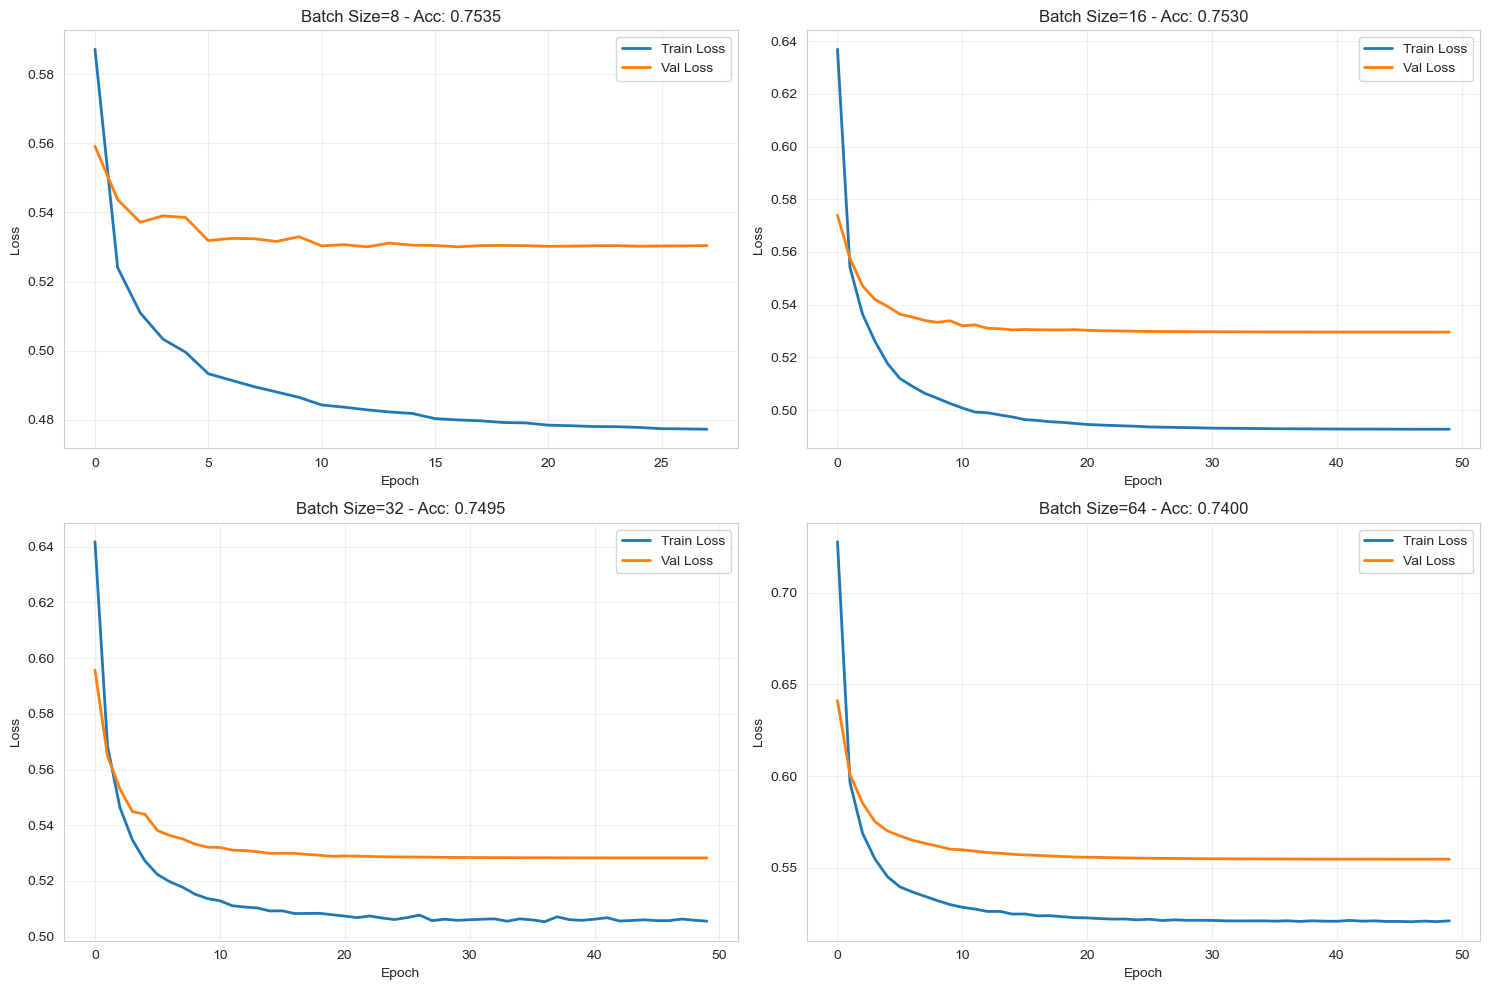

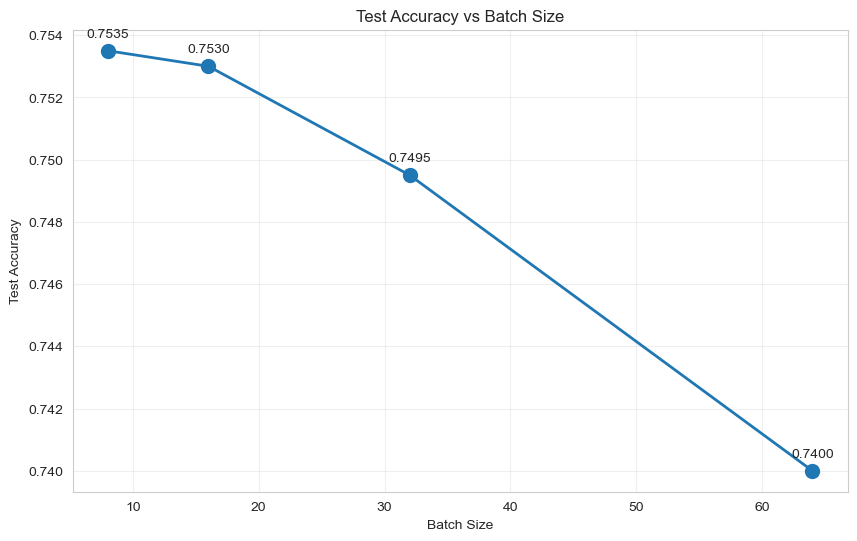


Hasil Eksperimen 4 (Batch Size):
  Batch Size=8: Acc=0.7535, Train Loss=0.4773, Val Loss=0.5304
  Batch Size=16: Acc=0.7530, Train Loss=0.4927, Val Loss=0.5296
  Batch Size=32: Acc=0.7495, Train Loss=0.5055, Val Loss=0.5283
  Batch Size=64: Acc=0.7400, Train Loss=0.5211, Val Loss=0.5547


In [11]:
# Plot perbandingan batch size
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, (batch_size, result) in enumerate(batch_results.items()):
    axes[i].plot(result['history']['train_loss'], label='Train Loss', linewidth=2)
    axes[i].plot(result['history']['val_loss'], label='Val Loss', linewidth=2)
    axes[i].set_title(f'Batch Size={batch_size} - Acc: {result["accuracy"]:.4f}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/experiment4_batch_size.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot akurasi vs batch size
fig, ax = plt.subplots(figsize=(10, 6))
batch_sizes_list = list(batch_results.keys())
accuracies = [batch_results[bs]['accuracy'] for bs in batch_sizes_list]
ax.plot(batch_sizes_list, accuracies, 'o-', linewidth=2, markersize=10)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Test Accuracy')
ax.set_title('Test Accuracy vs Batch Size')
ax.grid(True, alpha=0.3)
for i, bs in enumerate(batch_sizes_list):
    ax.annotate(f'{accuracies[i]:.4f}', (bs, accuracies[i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.savefig('../data/experiment4_batch_size_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nHasil Eksperimen 4 (Batch Size):")
for batch_size, result in batch_results.items():
    print(f"  Batch Size={batch_size}: Acc={result['accuracy']:.4f}, Train Loss={result['final_train_loss']:.4f}, Val Loss={result['final_val_loss']:.4f}")

## 7. Eksperimen 5: Pengaruh Initializer

Menganalisis pengaruh metode inisialisasi bobot terhadap training

In [12]:
# Konfigurasi initializers
initializers = ['zero', 'uniform', 'normal', 'xavier', 'he']

init_results = {}

for initializer in initializers:
    print(f"\n{'='*60}")
    print(f"Testing: {initializer.upper()} Initializer")
    print(f"{'='*60}")
    
    model = FFNN(
        layer_sizes=[n_features, 32, 16, n_classes],
        activations=['relu', 'relu', 'softmax'],
        loss_function='categorical_cross_entropy',
        initializer=initializer,
        learning_rate=0.01
    )
    
    # Simpan bobot awal untuk analisis
    initial_weights = [w.copy() for w in model.weights]
    
    history = model.train(
        X_train, y_train, X_val, y_val,
        batch_size=32,
        learning_rate=0.01,
        epochs=epochs,
        verbose=1
    )
    
    # Evaluasi
    y_pred = model.predict(X_test)
    acc = accuracy(y_test, y_pred)
    
    init_results[initializer] = {
        'model': model,
        'history': history,
        'accuracy': acc,
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1],
        'initial_weights': initial_weights
    }
    
    print(f"Test Accuracy: {acc:.4f}")


Testing: ZERO Initializer
Epoch 1/50 - Train Loss: 0.6787 - Val Loss: 0.6705
Epoch 2/50 - Train Loss: 0.6684 - Val Loss: 0.6670
Epoch 3/50 - Train Loss: 0.6666 - Val Loss: 0.6664
Epoch 4/50 - Train Loss: 0.6666 - Val Loss: 0.6663
  >> Reducing LR: 0.005000
Epoch 5/50 - Train Loss: 0.6666 - Val Loss: 0.6662
Epoch 6/50 - Train Loss: 0.6665 - Val Loss: 0.6662
Epoch 7/50 - Train Loss: 0.6664 - Val Loss: 0.6662
Epoch 8/50 - Train Loss: 0.6664 - Val Loss: 0.6662
Epoch 9/50 - Train Loss: 0.6662 - Val Loss: 0.6662
  >> Reducing LR: 0.002500
Epoch 10/50 - Train Loss: 0.6662 - Val Loss: 0.6662
Epoch 11/50 - Train Loss: 0.6662 - Val Loss: 0.6662
Epoch 12/50 - Train Loss: 0.6665 - Val Loss: 0.6662
Epoch 13/50 - Train Loss: 0.6662 - Val Loss: 0.6662
Epoch 14/50 - Train Loss: 0.6662 - Val Loss: 0.6662
  >> Reducing LR: 0.001250
Epoch 15/50 - Train Loss: 0.6662 - Val Loss: 0.6662
Epoch 16/50 - Train Loss: 0.6663 - Val Loss: 0.6662
Epoch 17/50 - Train Loss: 0.6662 - Val Loss: 0.6662
Epoch 18/50 - Tra

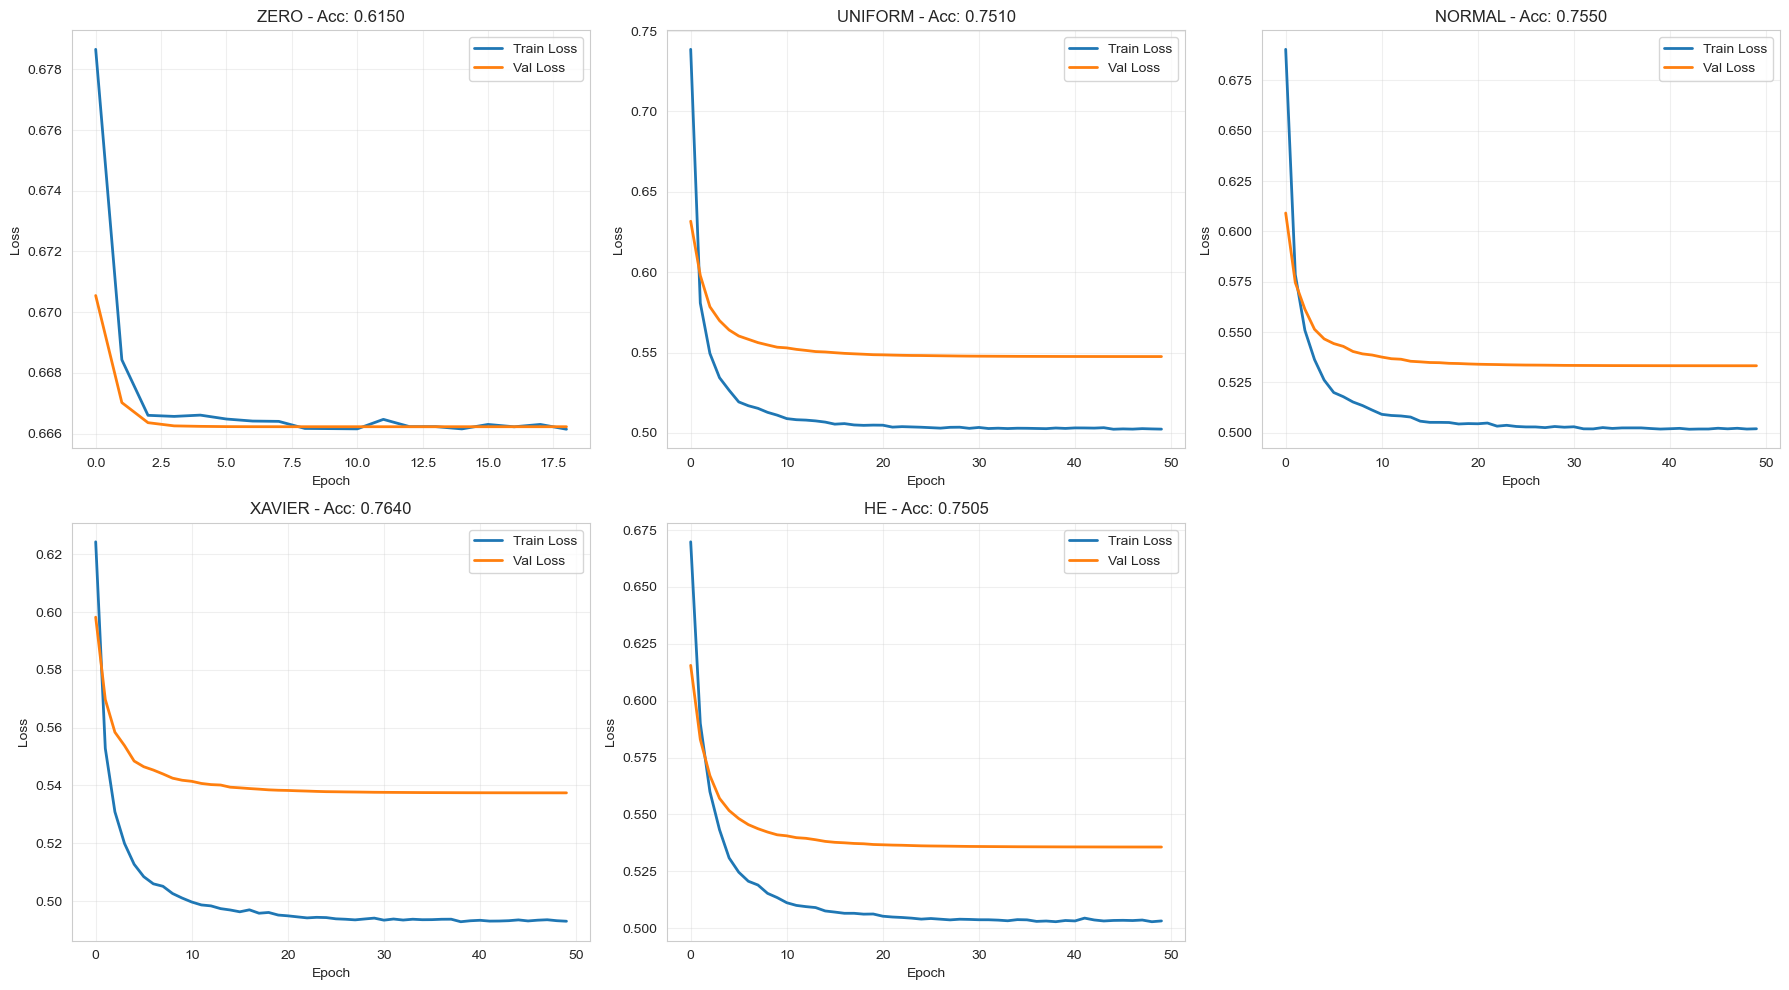

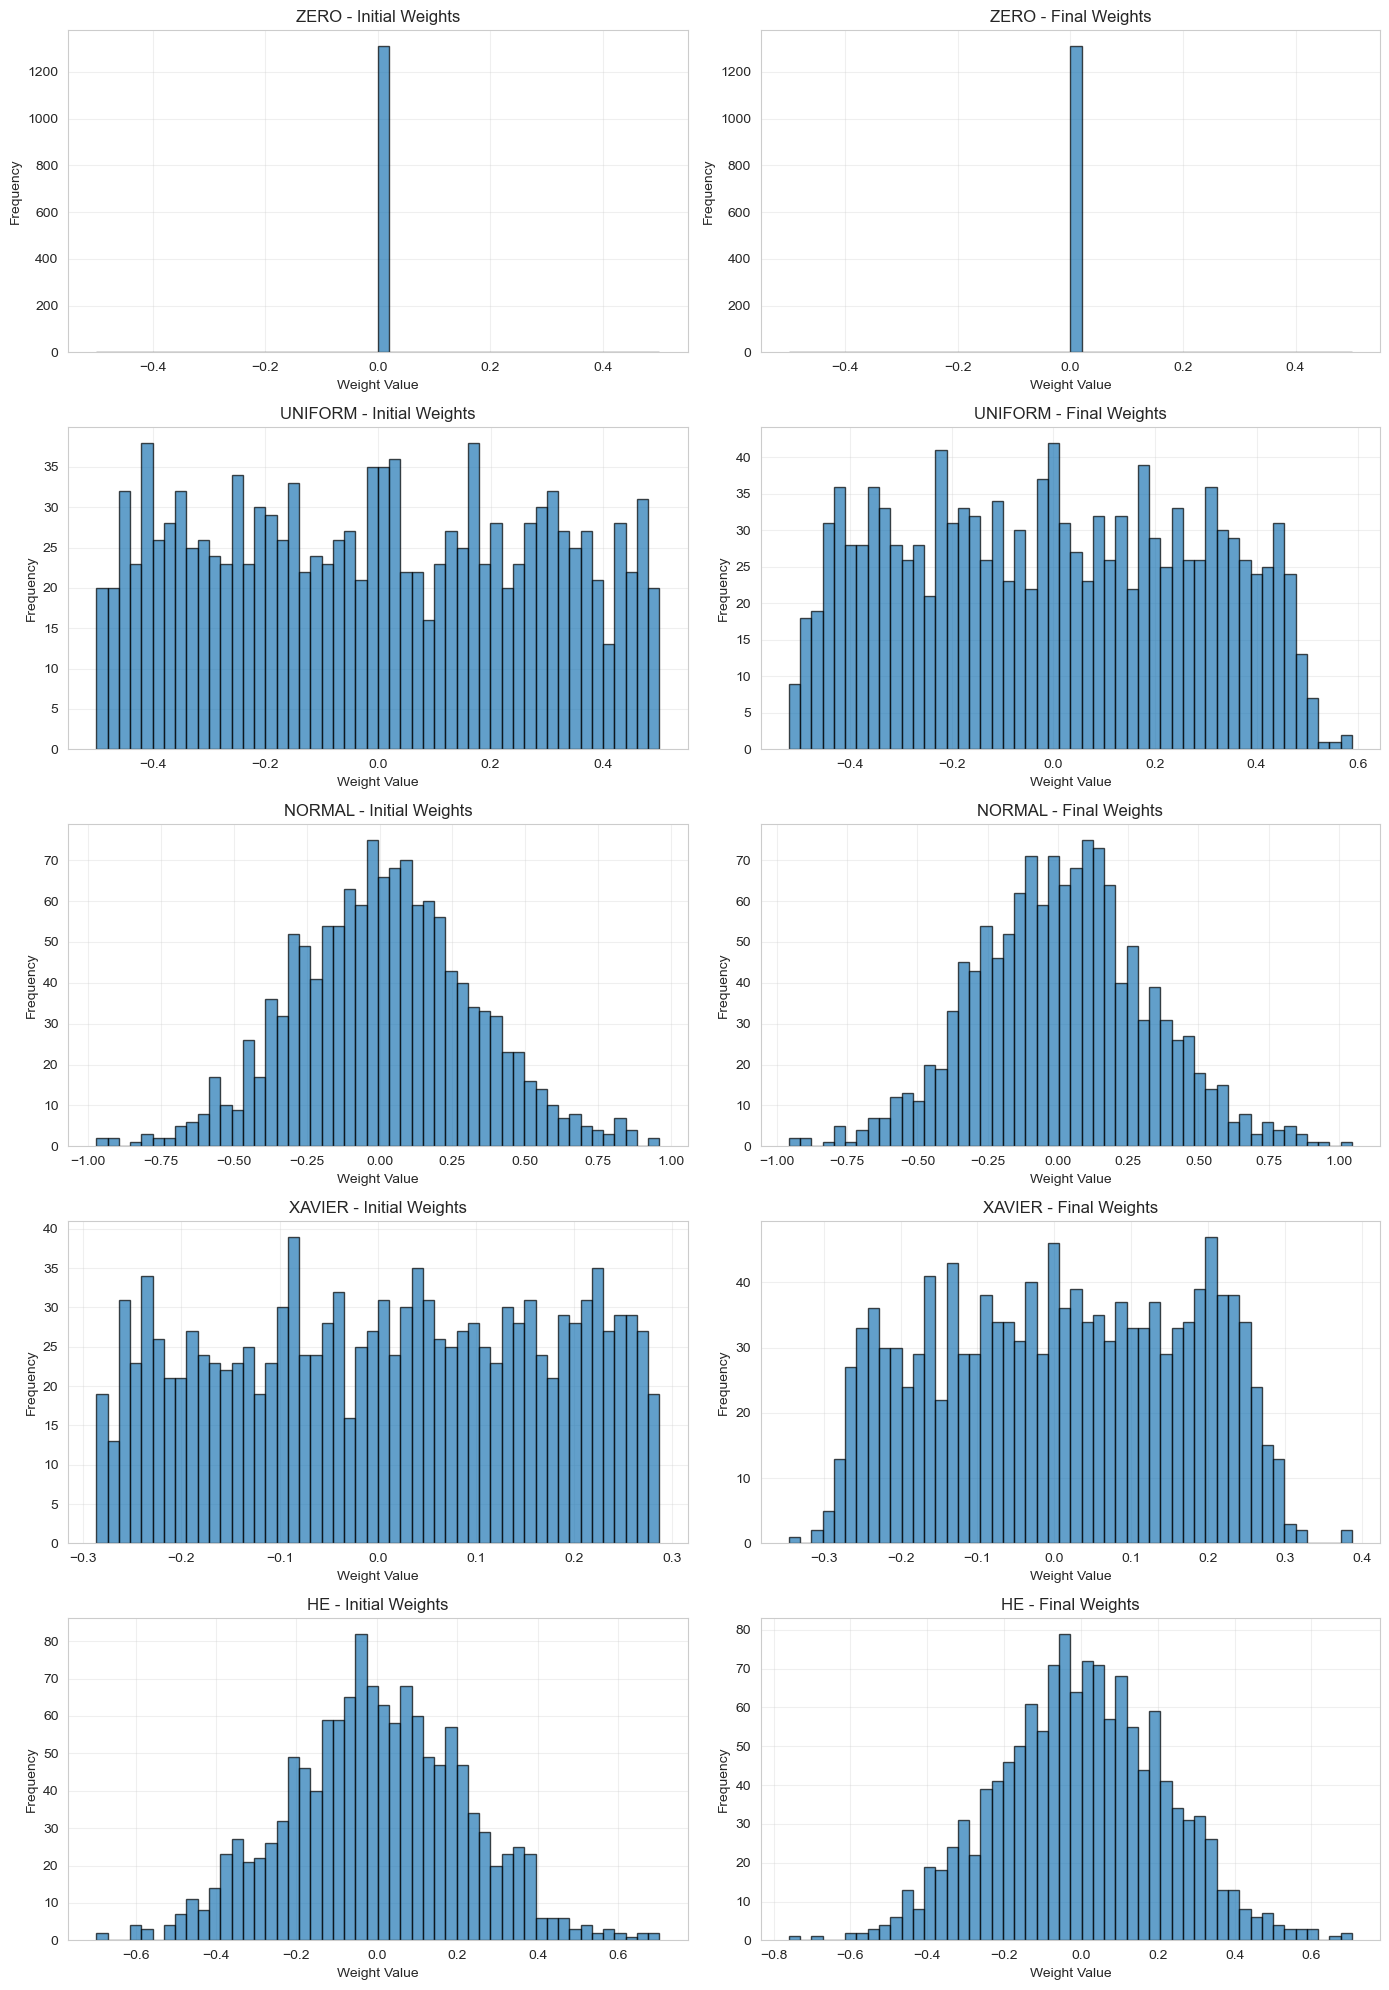


Hasil Eksperimen 5 (Initializer):
  zero: Acc=0.6150, Train Loss=0.6661, Val Loss=0.6662
  uniform: Acc=0.7510, Train Loss=0.5024, Val Loss=0.5475
  normal: Acc=0.7550, Train Loss=0.5019, Val Loss=0.5333
  xavier: Acc=0.7640, Train Loss=0.4930, Val Loss=0.5374
  he: Acc=0.7505, Train Loss=0.5032, Val Loss=0.5357


In [13]:
# Plot perbandingan initializer - Training Loss
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (init_name, result) in enumerate(init_results.items()):
    axes[i].plot(result['history']['train_loss'], label='Train Loss', linewidth=2)
    axes[i].plot(result['history']['val_loss'], label='Val Loss', linewidth=2)
    axes[i].set_title(f'{init_name.upper()} - Acc: {result["accuracy"]:.4f}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# Remove empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig('../data/experiment5_initializer.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot distribusi bobot awal vs akhir untuk beberapa initializer
fig, axes = plt.subplots(len(initializers), 2, figsize=(14, 20))

for i, (init_name, result) in enumerate(init_results.items()):
    # Bobot awal
    init_w = result['initial_weights'][0]  # Layer pertama
    axes[i, 0].hist(init_w.flatten(), bins=50, alpha=0.7, edgecolor='black')
    axes[i, 0].set_title(f'{init_name.upper()} - Initial Weights')
    axes[i, 0].set_xlabel('Weight Value')
    axes[i, 0].set_ylabel('Frequency')
    axes[i, 0].grid(True, alpha=0.3)
    
    # Bobot akhir
    final_w = result['model'].weights[0]
    axes[i, 1].hist(final_w.flatten(), bins=50, alpha=0.7, edgecolor='black')
    axes[i, 1].set_title(f'{init_name.upper()} - Final Weights')
    axes[i, 1].set_xlabel('Weight Value')
    axes[i, 1].set_ylabel('Frequency')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/experiment5_initializer_weights.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nHasil Eksperimen 5 (Initializer):")
for init_name, result in init_results.items():
    print(f"  {init_name}: Acc={result['accuracy']:.4f}, Train Loss={result['final_train_loss']:.4f}, Val Loss={result['final_val_loss']:.4f}")

## 8. Eksperimen 6: Pengaruh Optimizer

Menganalisis pengaruh optimizer (SGD vs Adam) terhadap training

In [14]:
# Import optimizers
from src.optimizers import GradientDescent, Adam

# Konfigurasi optimizers
optimizer_configs = [
    {'name': 'SGD', 'optimizer': GradientDescent(learning_rate=0.01)},
    {'name': 'Adam', 'optimizer': Adam(learning_rate=0.001)},
    {'name': 'Adam (lr=0.01)', 'optimizer': Adam(learning_rate=0.01)}
]

opt_results = {}

for config in optimizer_configs:
    print(f"\n{'='*60}")
    print(f"Testing: {config['name']}")
    print(f"{'='*60}")
    
    # Reset optimizer state untuk training baru
    opt = config['optimizer']
    if hasattr(opt, 'reset'):
        opt.reset()
    
    model = FFNN(
        layer_sizes=[n_features, 32, 16, n_classes],
        activations=['relu', 'relu', 'softmax'],
        loss_function='categorical_cross_entropy',
        initializer='xavier',
        learning_rate=0.01
    )
    
    history = model.train(
        X_train, y_train, X_val, y_val,
        batch_size=32,
        learning_rate=0.01,
        epochs=epochs,
        optimizer=opt,
        verbose=1
    )
    
    # Evaluasi
    y_pred = model.predict(X_test)
    acc = accuracy(y_test, y_pred)
    
    opt_results[config['name']] = {
        'model': model,
        'history': history,
        'accuracy': acc,
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1],
        'optimizer': opt
    }
    
    print(f"Test Accuracy: {acc:.4f}")


Testing: SGD
Epoch 1/50 - Train Loss: 0.6051 - Val Loss: 0.5766
Epoch 2/50 - Train Loss: 0.5557 - Val Loss: 0.5549
Epoch 3/50 - Train Loss: 0.5347 - Val Loss: 0.5451
Epoch 4/50 - Train Loss: 0.5226 - Val Loss: 0.5389
Epoch 5/50 - Train Loss: 0.5139 - Val Loss: 0.5359
Epoch 6/50 - Train Loss: 0.5071 - Val Loss: 0.5327
Epoch 7/50 - Train Loss: 0.5038 - Val Loss: 0.5310
Epoch 8/50 - Train Loss: 0.4995 - Val Loss: 0.5293
Epoch 9/50 - Train Loss: 0.4971 - Val Loss: 0.5283
Epoch 10/50 - Train Loss: 0.4940 - Val Loss: 0.5278
Epoch 11/50 - Train Loss: 0.4926 - Val Loss: 0.5271
Epoch 12/50 - Train Loss: 0.4895 - Val Loss: 0.5271
Epoch 13/50 - Train Loss: 0.4880 - Val Loss: 0.5263
Epoch 14/50 - Train Loss: 0.4868 - Val Loss: 0.5266
Epoch 15/50 - Train Loss: 0.4844 - Val Loss: 0.5260
Epoch 16/50 - Train Loss: 0.4835 - Val Loss: 0.5255
Epoch 17/50 - Train Loss: 0.4829 - Val Loss: 0.5259
Epoch 18/50 - Train Loss: 0.4806 - Val Loss: 0.5271
Epoch 19/50 - Train Loss: 0.4800 - Val Loss: 0.5260
Epoch 2

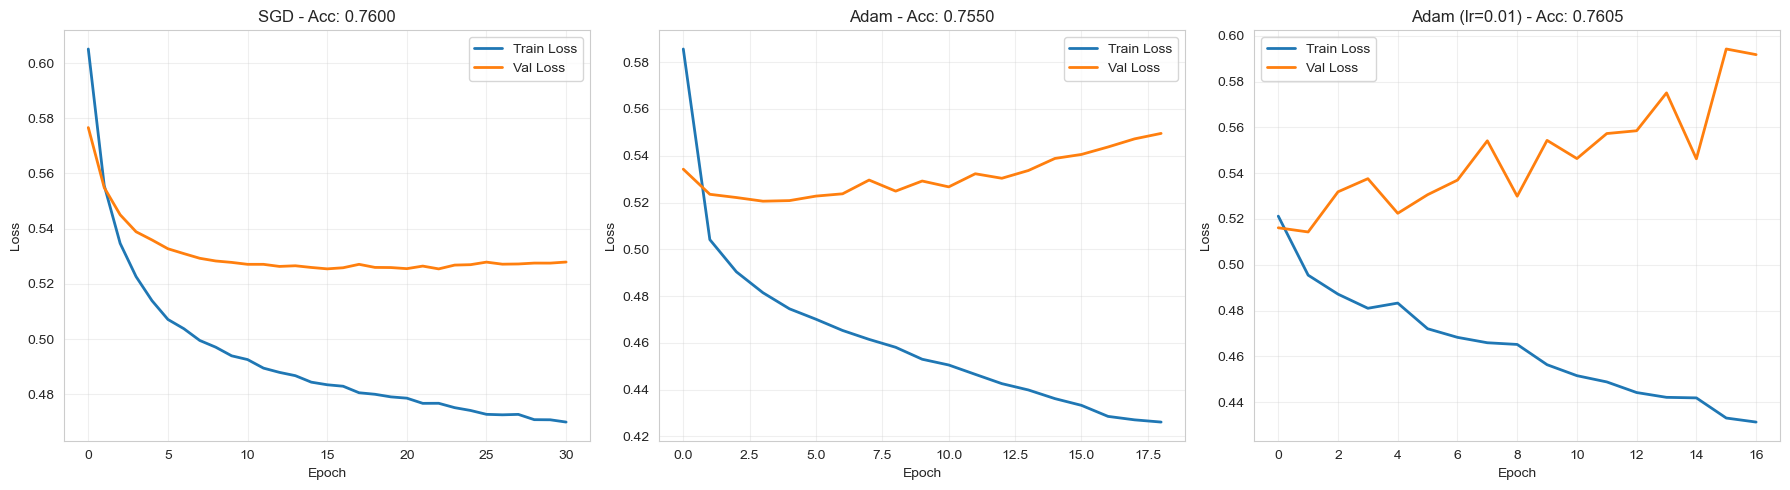

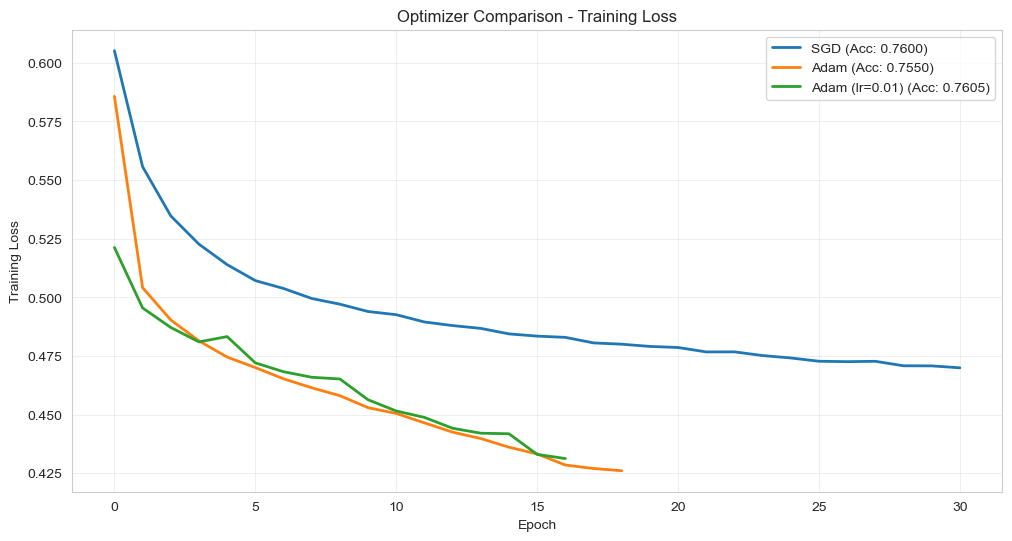


Hasil Eksperimen 6 (Optimizer):
  SGD: Acc=0.7600, Train Loss=0.4700, Val Loss=0.5279
  Adam: Acc=0.7550, Train Loss=0.4261, Val Loss=0.5495
  Adam (lr=0.01): Acc=0.7605, Train Loss=0.4313, Val Loss=0.5918


In [15]:
# Plot perbandingan optimizer
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (opt_name, result) in enumerate(opt_results.items()):
    axes[i].plot(result['history']['train_loss'], label='Train Loss', linewidth=2)
    axes[i].plot(result['history']['val_loss'], label='Val Loss', linewidth=2)
    axes[i].set_title(f'{opt_name} - Acc: {result["accuracy"]:.4f}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/experiment6_optimizer.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot perbandingan langsung semua optimizer
fig, ax = plt.subplots(figsize=(12, 6))

for opt_name, result in opt_results.items():
    ax.plot(result['history']['train_loss'], label=f'{opt_name} (Acc: {result["accuracy"]:.4f})', linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Optimizer Comparison - Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('../data/experiment6_optimizer_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nHasil Eksperimen 6 (Optimizer):")
for opt_name, result in opt_results.items():
    print(f"  {opt_name}: Acc={result['accuracy']:.4f}, Train Loss={result['final_train_loss']:.4f}, Val Loss={result['final_val_loss']:.4f}")

In [16]:
# Konfigurasi regularisasi
# layer_sizes = [n_features, 64, 32, n_classes] -> 4 layers
regularization_configs = [
    {'name': 'No Regularization', 'regularizer': None, 'dropout_rate': 0.0},
    {'name': 'L1 (lambda=0.001)', 'regularizer': {'type': 'l1', 'lambda_param': 0.001}, 'dropout_rate': 0.0},
    {'name': 'L1 (lambda=0.01)', 'regularizer': {'type': 'l1', 'lambda_param': 0.01}, 'dropout_rate': 0.0},
    {'name': 'L2 (lambda=0.001)', 'regularizer': {'type': 'l2', 'lambda_param': 0.001}, 'dropout_rate': 0.0},
    {'name': 'L2 (lambda=0.01)', 'regularizer': {'type': 'l2', 'lambda_param': 0.01}, 'dropout_rate': 0.0},
    {'name': 'Dropout (0.2)', 'regularizer': None, 'dropout_rate': 0.2},
    {'name': 'Dropout (0.5)', 'regularizer': None, 'dropout_rate': 0.5},
]

reg_results = {}

In [17]:
# Konfigurasi regularisasi
regularization_configs = [
    {'name': 'No Regularization', 'regularizer': None, 'dropout_rate': 0.0},
    {'name': 'L1 (lambda=0.001)', 'regularizer': {'type': 'l1', 'lambda_param': 0.001}, 'dropout_rate': 0.0},
    {'name': 'L1 (lambda=0.01)', 'regularizer': {'type': 'l1', 'lambda_param': 0.01}, 'dropout_rate': 0.0},
    {'name': 'L2 (lambda=0.001)', 'regularizer': {'type': 'l2', 'lambda_param': 0.001}, 'dropout_rate': 0.0},
    {'name': 'L2 (lambda=0.01)', 'regularizer': {'type': 'l2', 'lambda_param': 0.01}, 'dropout_rate': 0.0},
    {'name': 'Dropout (0.2)', 'regularizer': None, 'dropout_rate': 0.2},
    {'name': 'Dropout (0.5)', 'regularizer': None, 'dropout_rate': 0.5},
]

reg_results = {}

for config in regularization_configs:
    print(f"\n{'='*60}")
    print(f"Testing: {config['name']}")
    print(f"{'='*60}")
    
    model = FFNN(
        layer_sizes=[n_features, 64, 32, n_classes],  # Lebih besar untuk menunjukkan efek regularisasi
        activations=['relu', 'relu', 'softmax'],
        loss_function='categorical_cross_entropy',
        initializer='xavier',
        learning_rate=0.01,
        regularizer=config['regularizer'],
        dropout_rate=config['dropout_rate']
    )
    
    history = model.train(
        X_train, y_train, X_val, y_val,
        batch_size=32,
        learning_rate=0.01,
        epochs=epochs,
        verbose=1
    )
    
    # Evaluasi
    y_pred = model.predict(X_test)
    acc = accuracy(y_test, y_pred)
    
    reg_results[config['name']] = {
        'model': model,
        'history': history,
        'accuracy': acc,
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1]
    }
    
    print(f"Test Accuracy: {acc:.4f}")


Testing: No Regularization
Epoch 1/50 - Train Loss: 0.6186 - Val Loss: 0.5629
Epoch 2/50 - Train Loss: 0.5349 - Val Loss: 0.5367
Epoch 3/50 - Train Loss: 0.5146 - Val Loss: 0.5287
Epoch 4/50 - Train Loss: 0.5054 - Val Loss: 0.5256
  >> Reducing LR: 0.005000
Epoch 5/50 - Train Loss: 0.4999 - Val Loss: 0.5241
Epoch 6/50 - Train Loss: 0.4949 - Val Loss: 0.5234
Epoch 7/50 - Train Loss: 0.4935 - Val Loss: 0.5232
Epoch 8/50 - Train Loss: 0.4920 - Val Loss: 0.5226
Epoch 9/50 - Train Loss: 0.4903 - Val Loss: 0.5222
  >> Reducing LR: 0.002500
Epoch 10/50 - Train Loss: 0.4886 - Val Loss: 0.5220
Epoch 11/50 - Train Loss: 0.4867 - Val Loss: 0.5219
Epoch 12/50 - Train Loss: 0.4866 - Val Loss: 0.5219
Epoch 13/50 - Train Loss: 0.4862 - Val Loss: 0.5217
Epoch 14/50 - Train Loss: 0.4856 - Val Loss: 0.5216
  >> Reducing LR: 0.001250
Epoch 15/50 - Train Loss: 0.4847 - Val Loss: 0.5216
Epoch 16/50 - Train Loss: 0.4840 - Val Loss: 0.5215
Epoch 17/50 - Train Loss: 0.4839 - Val Loss: 0.5215
Epoch 18/50 - Tr

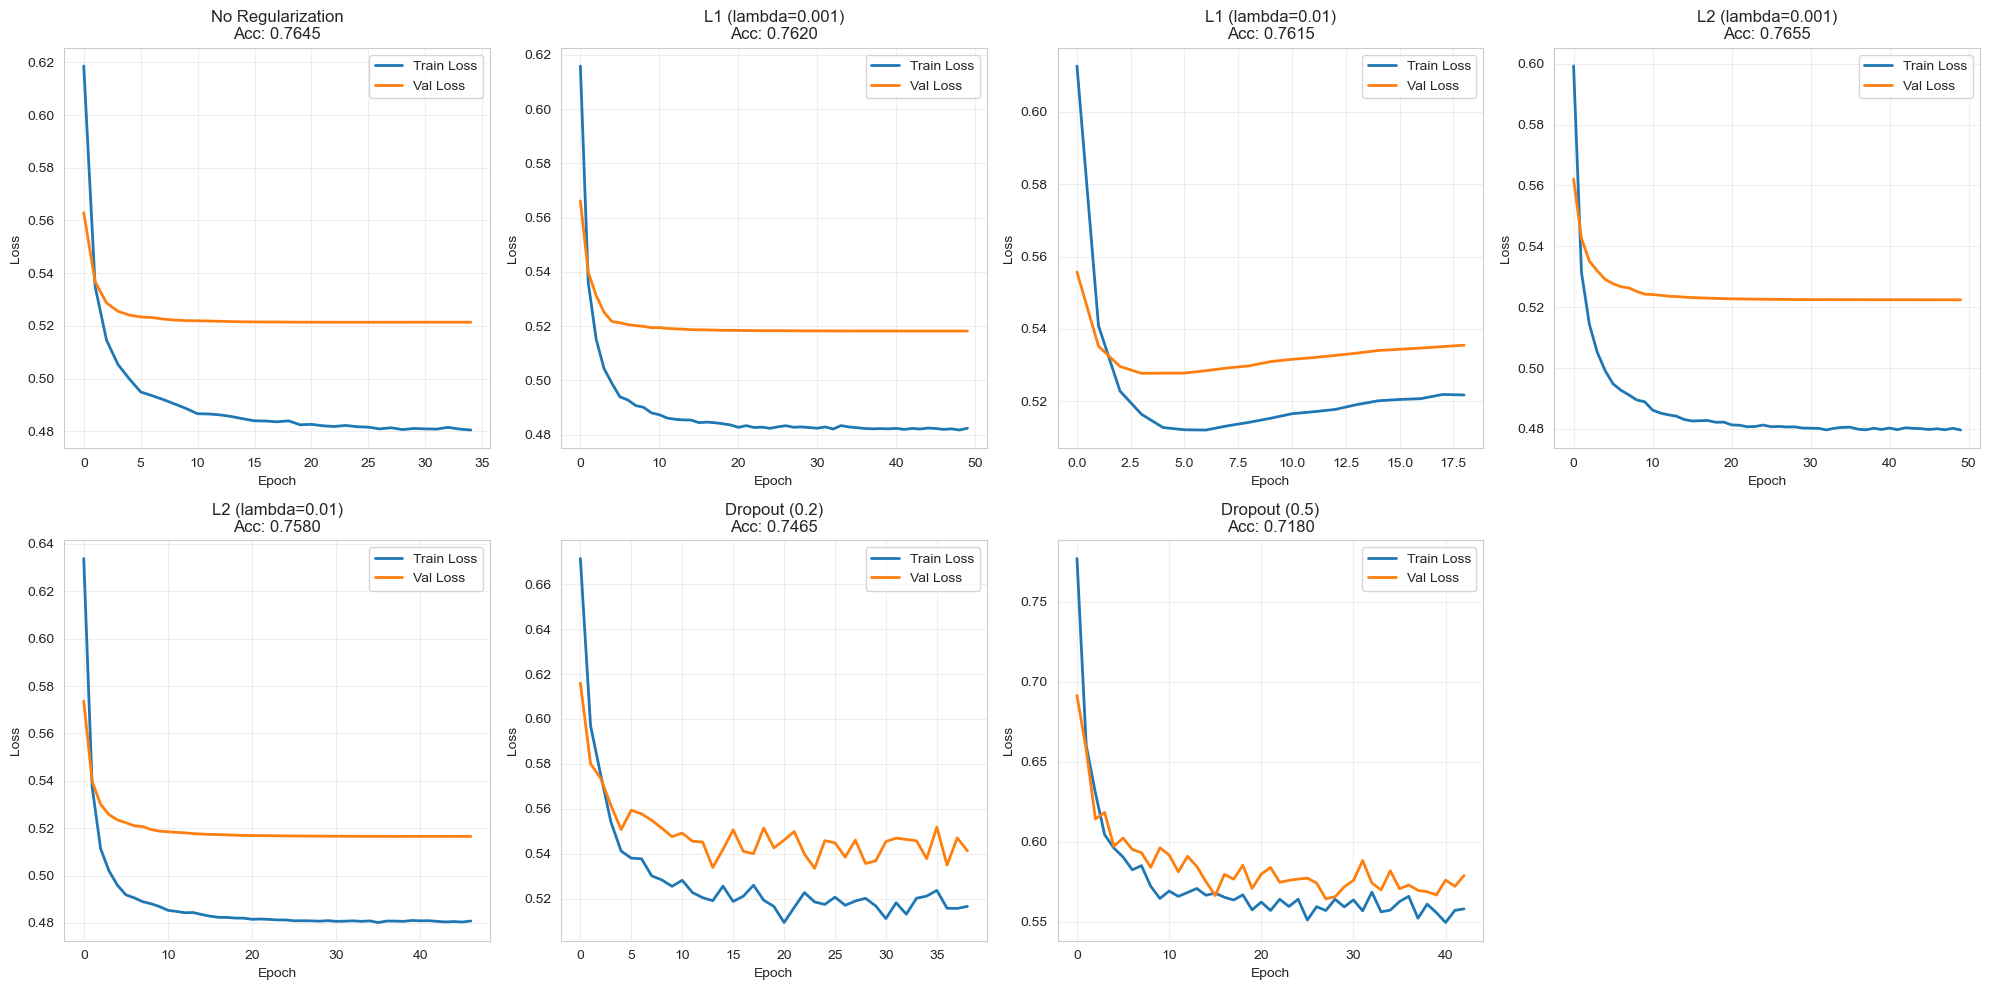

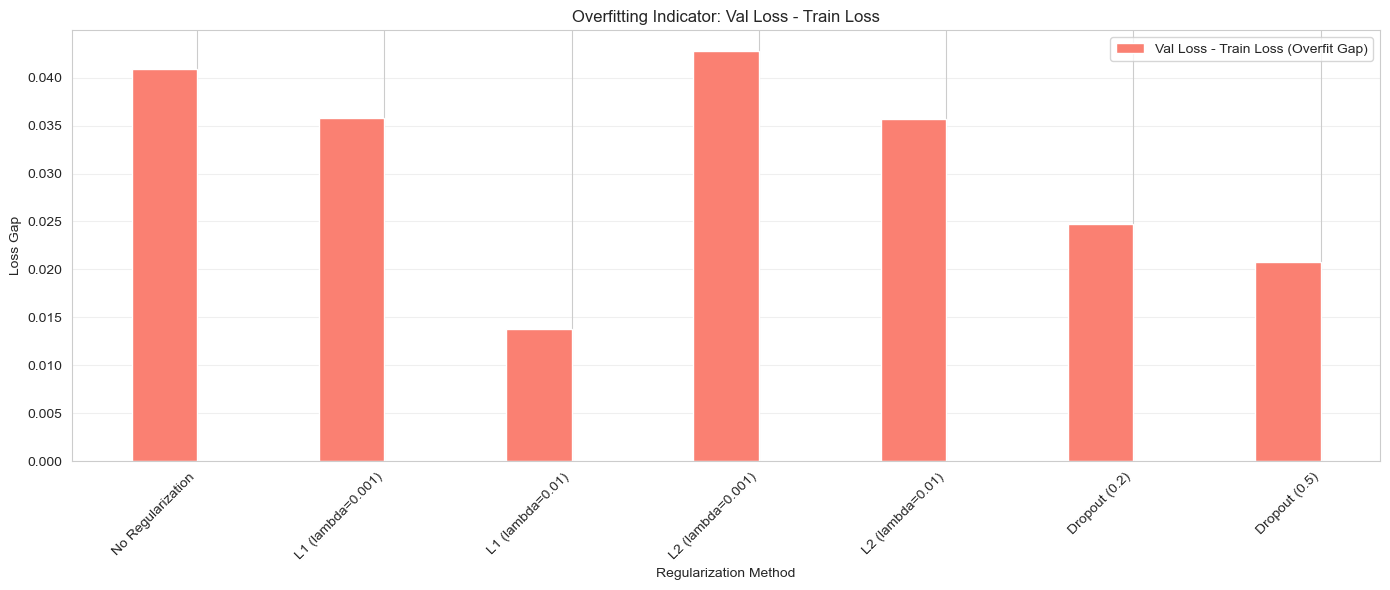


Hasil Eksperimen 7 (Regularisasi):
  No Regularization: Acc=0.7645, Train Loss=0.4805, Val Loss=0.5214
  L1 (lambda=0.001): Acc=0.7620, Train Loss=0.4824, Val Loss=0.5182
  L1 (lambda=0.01): Acc=0.7615, Train Loss=0.5217, Val Loss=0.5355
  L2 (lambda=0.001): Acc=0.7655, Train Loss=0.4796, Val Loss=0.5224
  L2 (lambda=0.01): Acc=0.7580, Train Loss=0.4808, Val Loss=0.5165
  Dropout (0.2): Acc=0.7465, Train Loss=0.5167, Val Loss=0.5414
  Dropout (0.5): Acc=0.7180, Train Loss=0.5579, Val Loss=0.5787


In [18]:
# Plot perbandingan regularisasi
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (reg_name, result) in enumerate(reg_results.items()):
    axes[i].plot(result['history']['train_loss'], label='Train Loss', linewidth=2)
    axes[i].plot(result['history']['val_loss'], label='Val Loss', linewidth=2)
    axes[i].set_title(f'{reg_name}\nAcc: {result["accuracy"]:.4f}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# Remove empty subplot
axes[7].axis('off')

plt.tight_layout()
plt.savefig('../data/experiment7_regularization.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot perbandingan val loss gap (overfitting indicator)
fig, ax = plt.subplots(figsize=(14, 6))

reg_names = list(reg_results.keys())
val_gaps = [reg_results[name]['final_val_loss'] - reg_results[name]['final_train_loss'] for name in reg_names]
accuracies = [reg_results[name]['accuracy'] for name in reg_names]

x = np.arange(len(reg_names))
width = 0.35

bars1 = ax.bar(x - width/2, val_gaps, width, label='Val Loss - Train Loss (Overfit Gap)', color='salmon')
ax.set_xlabel('Regularization Method')
ax.set_ylabel('Loss Gap')
ax.set_title('Overfitting Indicator: Val Loss - Train Loss')
ax.set_xticks(x)
ax.set_xticklabels(reg_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../data/experiment7_regularization_overfit.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nHasil Eksperimen 7 (Regularisasi):")
for reg_name, result in reg_results.items():
    print(f"  {reg_name}: Acc={result['accuracy']:.4f}, Train Loss={result['final_train_loss']:.4f}, Val Loss={result['final_val_loss']:.4f}")

In [23]:
# Konfigurasi normalisasi
# normalization list: None, 'rmsnorm', 'layernorm' untuk setiap layer (kecuali output)
normalization_configs = [
    {'name': 'No Normalization', 'normalization': [None, None, None]},
    {'name': 'RMSNorm', 'normalization': ['rmsnorm', 'rmsnorm', None]},
    {'name': 'LayerNorm', 'normalization': ['layernorm', 'layernorm', None]},
]

norm_results = {}

for config in normalization_configs:
    print(f"\n{'='*60}")
    print(f"Testing: {config['name']}")
    print(f"{'='*60}")
    
    model = FFNN(
        layer_sizes=[n_features, 64, 32, n_classes],
        activations=['relu', 'relu', 'softmax'],
        loss_function='categorical_cross_entropy',
        initializer='xavier',
        learning_rate=0.01,
        normalization=config['normalization']
    )
    
    history = model.train(
        X_train, y_train, X_val, y_val,
        batch_size=32,
        learning_rate=0.01,
        epochs=epochs,
        verbose=1
    )
    
    # Evaluasi
    y_pred = model.predict(X_test)
    acc = accuracy(y_test, y_pred)
    
    norm_results[config['name']] = {
        'model': model,
        'history': history,
        'accuracy': acc,
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1]
    }
    
    print(f"Test Accuracy: {acc:.4f}")


Testing: No Normalization
Epoch 1/50 - Train Loss: 0.6142 - Val Loss: 0.5610
Epoch 2/50 - Train Loss: 0.5354 - Val Loss: 0.5366
Epoch 3/50 - Train Loss: 0.5154 - Val Loss: 0.5308
Epoch 4/50 - Train Loss: 0.5057 - Val Loss: 0.5288
  >> Reducing LR: 0.005000
Epoch 5/50 - Train Loss: 0.4996 - Val Loss: 0.5282
Epoch 6/50 - Train Loss: 0.4953 - Val Loss: 0.5273
Epoch 7/50 - Train Loss: 0.4924 - Val Loss: 0.5268
Epoch 8/50 - Train Loss: 0.4910 - Val Loss: 0.5271
Epoch 9/50 - Train Loss: 0.4896 - Val Loss: 0.5266
  >> Reducing LR: 0.002500
Epoch 10/50 - Train Loss: 0.4878 - Val Loss: 0.5262
Epoch 11/50 - Train Loss: 0.4863 - Val Loss: 0.5264
Epoch 12/50 - Train Loss: 0.4856 - Val Loss: 0.5265
Epoch 13/50 - Train Loss: 0.4852 - Val Loss: 0.5264
Epoch 14/50 - Train Loss: 0.4845 - Val Loss: 0.5263
  >> Reducing LR: 0.001250
Epoch 15/50 - Train Loss: 0.4846 - Val Loss: 0.5260
Epoch 16/50 - Train Loss: 0.4825 - Val Loss: 0.5261
Epoch 17/50 - Train Loss: 0.4825 - Val Loss: 0.5262
Epoch 18/50 - Tra

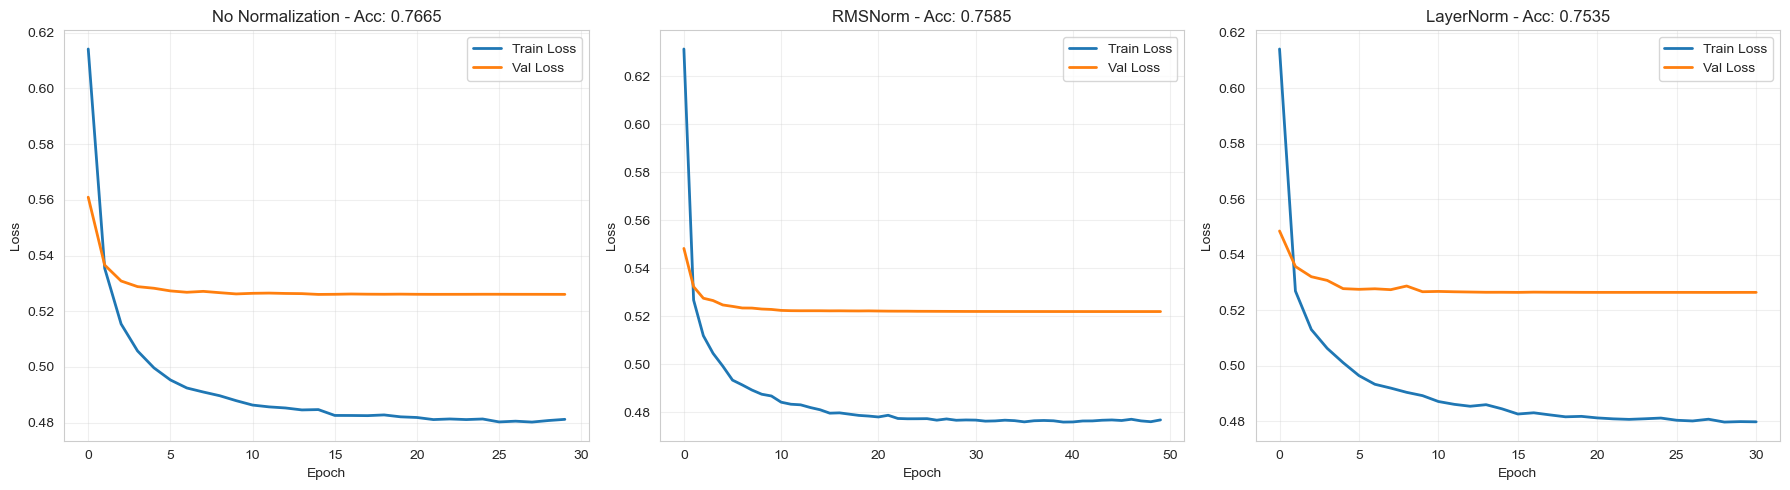

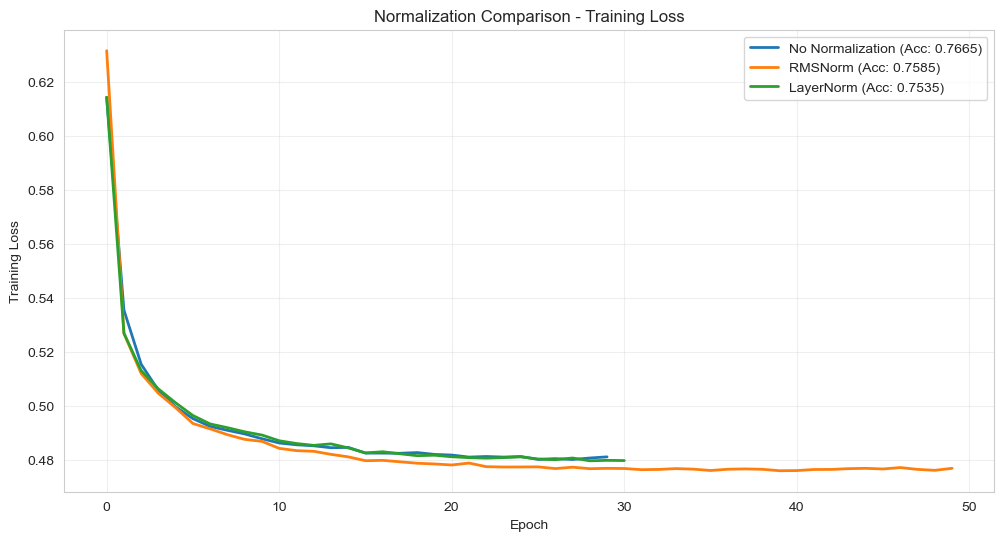


Hasil Eksperimen 8 (Normalisasi):
  No Normalization: Acc=0.7665, Train Loss=0.4811, Val Loss=0.5260
  RMSNorm: Acc=0.7585, Train Loss=0.4769, Val Loss=0.5220
  LayerNorm: Acc=0.7535, Train Loss=0.4798, Val Loss=0.5264


In [24]:
# Plot perbandingan normalisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (norm_name, result) in enumerate(norm_results.items()):
    axes[i].plot(result['history']['train_loss'], label='Train Loss', linewidth=2)
    axes[i].plot(result['history']['val_loss'], label='Val Loss', linewidth=2)
    axes[i].set_title(f'{norm_name} - Acc: {result["accuracy"]:.4f}')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/experiment8_normalization.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot perbandingan langsung
fig, ax = plt.subplots(figsize=(12, 6))

for norm_name, result in norm_results.items():
    ax.plot(result['history']['train_loss'], label=f'{norm_name} (Acc: {result["accuracy"]:.4f})', linewidth=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Training Loss')
ax.set_title('Normalization Comparison - Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.savefig('../data/experiment8_normalization_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nHasil Eksperimen 8 (Normalisasi):")
for norm_name, result in norm_results.items():
    print(f"  {norm_name}: Acc={result['accuracy']:.4f}, Train Loss={result['final_train_loss']:.4f}, Val Loss={result['final_val_loss']:.4f}")

## 11. Eksperimen 9: Perbandingan dengan sklearn MLPClassifier

Membandingkan performa FFNN kita dengan sklearn MLPClassifier

In [25]:
# Import sklearn MLPClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

print("\n" + "="*60)
print("Perbandingan FFNN vs sklearn MLPClassifier")
print("="*60)

# Train FFNN kita
print("\n[1] Training FFNN kita...")
ffnn_model = FFNN(
    layer_sizes=[n_features, 32, 16, n_classes],
    activations=['relu', 'relu', 'softmax'],
    loss_function='categorical_cross_entropy',
    initializer='xavier',
    learning_rate=0.01
)

ffnn_history = ffnn_model.train(
    X_train, y_train, X_val, y_val,
    batch_size=32,
    learning_rate=0.01,
    epochs=epochs,
    verbose=1
)

ffnn_pred = ffnn_model.predict(X_test)
ffnn_acc = accuracy(y_test, ffnn_pred)

print(f"\nFFNN Test Accuracy: {ffnn_acc:.4f}")

# Train sklearn MLPClassifier
print("\n[2] Training sklearn MLPClassifier...")

# Konfigurasi yang serupa
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation='relu',
    solver='adam',
    alpha=0.0001,  # L2 regularization default
    batch_size=32,
    learning_rate_init=0.01,
    max_iter=epochs,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.2,
    verbose=True
)

mlp.fit(X_train, y_train)
mlp_pred = mlp.predict(X_test)
mlp_acc = accuracy_score(y_test, mlp_pred)

print(f"\nsklearn MLPClassifier Test Accuracy: {mlp_acc:.4f}")


Perbandingan FFNN vs sklearn MLPClassifier

[1] Training FFNN kita...
Epoch 1/50 - Train Loss: 0.6338 - Val Loss: 0.5959
Epoch 2/50 - Train Loss: 0.5625 - Val Loss: 0.5607
Epoch 3/50 - Train Loss: 0.5334 - Val Loss: 0.5469
Epoch 4/50 - Train Loss: 0.5195 - Val Loss: 0.5410
  >> Reducing LR: 0.005000
Epoch 5/50 - Train Loss: 0.5111 - Val Loss: 0.5375
Epoch 6/50 - Train Loss: 0.5059 - Val Loss: 0.5367
Epoch 7/50 - Train Loss: 0.5041 - Val Loss: 0.5359
Epoch 8/50 - Train Loss: 0.5012 - Val Loss: 0.5355
Epoch 9/50 - Train Loss: 0.5000 - Val Loss: 0.5350
  >> Reducing LR: 0.002500
Epoch 10/50 - Train Loss: 0.4983 - Val Loss: 0.5349
Epoch 11/50 - Train Loss: 0.4966 - Val Loss: 0.5342
Epoch 12/50 - Train Loss: 0.4959 - Val Loss: 0.5339
Epoch 13/50 - Train Loss: 0.4954 - Val Loss: 0.5334
Epoch 14/50 - Train Loss: 0.4947 - Val Loss: 0.5334
  >> Reducing LR: 0.001250
Epoch 15/50 - Train Loss: 0.4940 - Val Loss: 0.5332
Epoch 16/50 - Train Loss: 0.4927 - Val Loss: 0.5330
Epoch 17/50 - Train Loss:

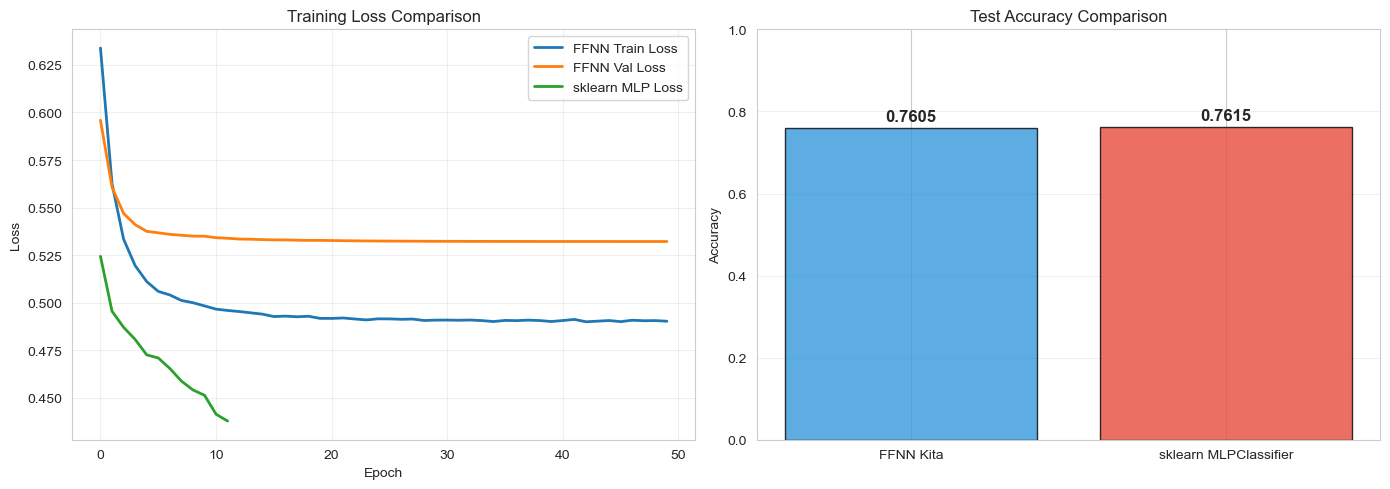


Classification Report - FFNN Kita
              precision    recall  f1-score   support

           0       0.71      0.64      0.67       770
           1       0.79      0.84      0.81      1230

    accuracy                           0.76      2000
   macro avg       0.75      0.74      0.74      2000
weighted avg       0.76      0.76      0.76      2000


Classification Report - sklearn MLPClassifier
              precision    recall  f1-score   support

           0       0.70      0.66      0.68       770
           1       0.79      0.83      0.81      1230

    accuracy                           0.76      2000
   macro avg       0.75      0.74      0.74      2000
weighted avg       0.76      0.76      0.76      2000


Hasil Eksperimen 9 (Perbandingan sklearn):
  FFNN Kita: 0.7605
  sklearn MLPClassifier: 0.7615
  Perbedaan: 0.0010


In [26]:
# Plot perbandingan FFNN vs sklearn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot training loss
axes[0].plot(ffnn_history['train_loss'], label='FFNN Train Loss', linewidth=2)
axes[0].plot(ffnn_history['val_loss'], label='FFNN Val Loss', linewidth=2)
axes[0].plot(mlp.loss_curve_, label='sklearn MLP Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot akurasi
models = ['FFNN Kita', 'sklearn MLPClassifier']
accuracies = [ffnn_acc, mlp_acc]
colors = ['#3498db', '#e74c3c']

bars = axes[1].bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Test Accuracy Comparison')
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[1].annotate(f'{acc:.4f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/experiment9_sklearn_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification reports
print("\n" + "="*60)
print("Classification Report - FFNN Kita")
print("="*60)
print(classification_report(y_test, ffnn_pred))

print("\n" + "="*60)
print("Classification Report - sklearn MLPClassifier")
print("="*60)
print(classification_report(y_test, mlp_pred))

print("\nHasil Eksperimen 9 (Perbandingan sklearn):")
print(f"  FFNN Kita: {ffnn_acc:.4f}")
print(f"  sklearn MLPClassifier: {mlp_acc:.4f}")
print(f"  Perbedaan: {abs(ffnn_acc - mlp_acc):.4f}")

## 12. Eksperimen 10: Learning Rate Scheduler

Menganalisis pengaruh learning rate scheduler terhadap training

In [27]:
# Konfigurasi learning rate scheduler
scheduler_configs = [
    {'name': 'Fixed LR (0.01)', 'lr_scheduler': None, 'learning_rate': 0.01},
    {'name': 'Plateau (factor=0.5)', 'lr_scheduler': 'plateau', 'lr_factor': 0.5, 'lr_patience': 5, 'learning_rate': 0.01},
    {'name': 'Plateau (factor=0.3)', 'lr_scheduler': 'plateau', 'lr_factor': 0.3, 'lr_patience': 5, 'learning_rate': 0.01},
]

scheduler_results = {}

for config in scheduler_configs:
    print(f"\n{'='*60}")
    print(f"Testing: {config['name']}")
    print(f"{'='*60}")
    
    model = FFNN(
        layer_sizes=[n_features, 32, 16, n_classes],
        activations=['relu', 'relu', 'softmax'],
        loss_function='categorical_cross_entropy',
        initializer='xavier',
        learning_rate=config['learning_rate']
    )
    
    history = model.train(
        X_train, y_train, X_val, y_val,
        batch_size=32,
        learning_rate=config['learning_rate'],
        epochs=epochs,
        lr_scheduler=config['lr_scheduler'],
        lr_factor=config.get('lr_factor', 0.5),
        lr_patience=config.get('lr_patience', 5),
        verbose=1
    )
    
    # Evaluasi
    y_pred = model.predict(X_test)
    acc = accuracy(y_test, y_pred)
    
    scheduler_results[config['name']] = {
        'model': model,
        'history': history,
        'accuracy': acc,
        'final_train_loss': history['train_loss'][-1],
        'final_val_loss': history['val_loss'][-1],
        'lr_history': history.get('learning_rate', [])
    }
    
    print(f"Test Accuracy: {acc:.4f}")


Testing: Fixed LR (0.01)
Epoch 1/50 - Train Loss: 0.6217 - Val Loss: 0.5932
Epoch 2/50 - Train Loss: 0.5544 - Val Loss: 0.5668
Epoch 3/50 - Train Loss: 0.5315 - Val Loss: 0.5555
Epoch 4/50 - Train Loss: 0.5196 - Val Loss: 0.5477
Epoch 5/50 - Train Loss: 0.5119 - Val Loss: 0.5424
Epoch 6/50 - Train Loss: 0.5070 - Val Loss: 0.5396
Epoch 7/50 - Train Loss: 0.5015 - Val Loss: 0.5364
Epoch 8/50 - Train Loss: 0.4982 - Val Loss: 0.5344
Epoch 9/50 - Train Loss: 0.4957 - Val Loss: 0.5329
Epoch 10/50 - Train Loss: 0.4931 - Val Loss: 0.5312
Epoch 11/50 - Train Loss: 0.4913 - Val Loss: 0.5303
Epoch 12/50 - Train Loss: 0.4886 - Val Loss: 0.5294
Epoch 13/50 - Train Loss: 0.4876 - Val Loss: 0.5283
Epoch 14/50 - Train Loss: 0.4855 - Val Loss: 0.5286
Epoch 15/50 - Train Loss: 0.4840 - Val Loss: 0.5278
Epoch 16/50 - Train Loss: 0.4826 - Val Loss: 0.5274
Epoch 17/50 - Train Loss: 0.4816 - Val Loss: 0.5265
Epoch 18/50 - Train Loss: 0.4801 - Val Loss: 0.5260
Epoch 19/50 - Train Loss: 0.4796 - Val Loss: 0.

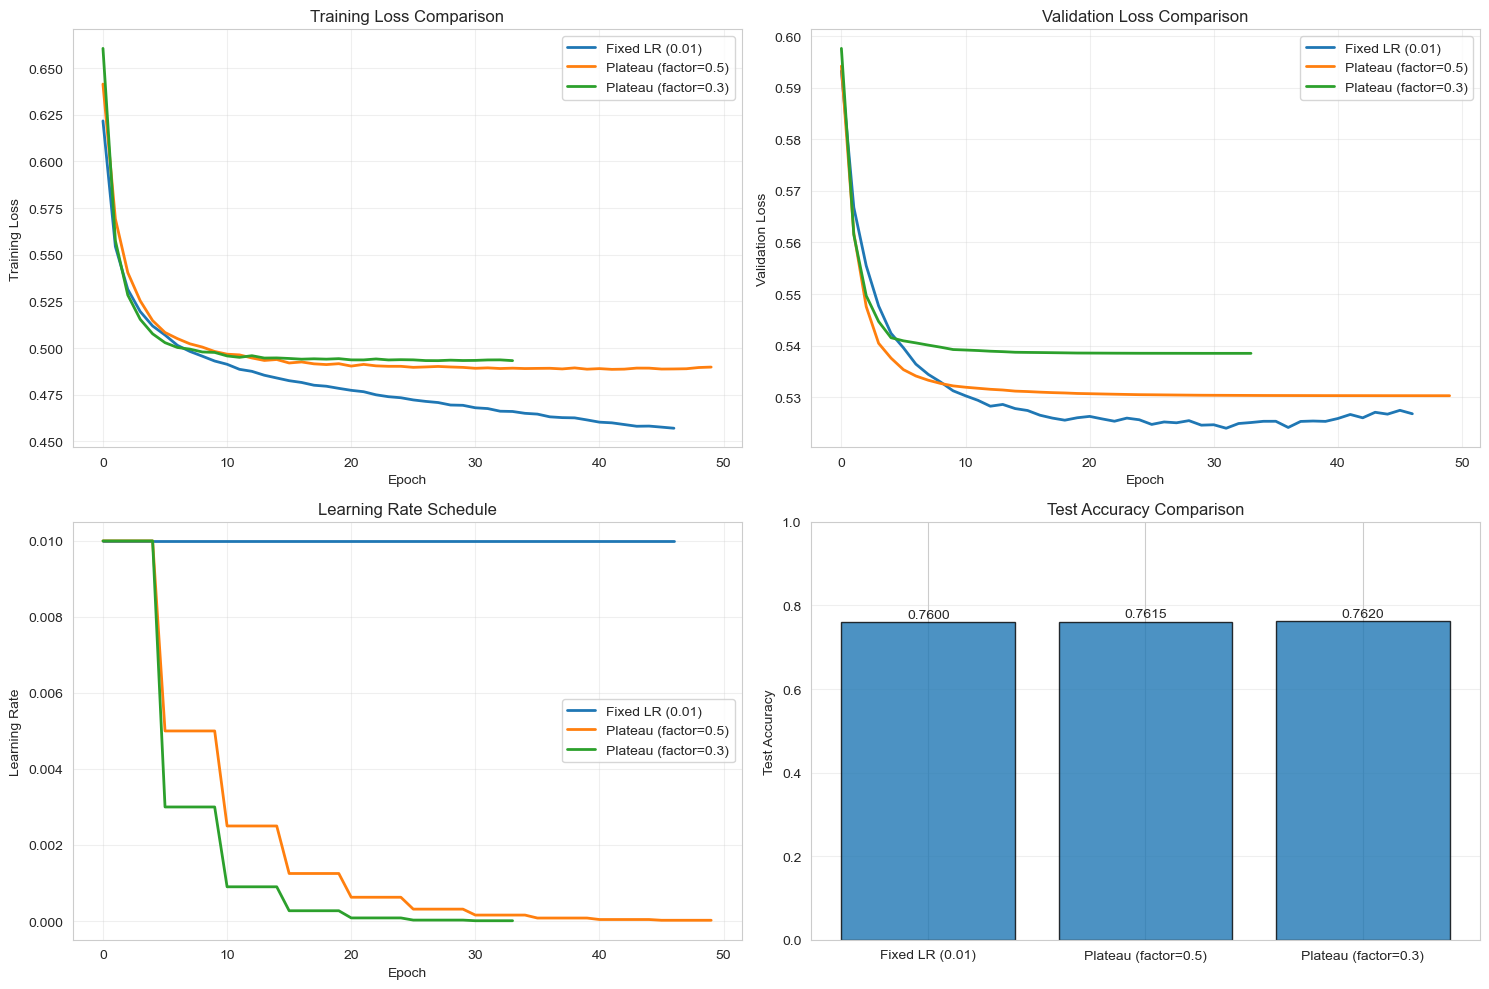


Hasil Eksperimen 10 (Learning Rate Scheduler):
  Fixed LR (0.01): Acc=0.7600, Train Loss=0.4571, Val Loss=0.5268
  Plateau (factor=0.5): Acc=0.7615, Train Loss=0.4899, Val Loss=0.5303
  Plateau (factor=0.3): Acc=0.7620, Train Loss=0.4933, Val Loss=0.5385


In [28]:
# Plot perbandingan LR scheduler
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Training Loss
for i, (sch_name, result) in enumerate(scheduler_results.items()):
    axes[0, 0].plot(result['history']['train_loss'], label=f'{sch_name}', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Training Loss')
axes[0, 0].set_title('Training Loss Comparison')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Validation Loss
for i, (sch_name, result) in enumerate(scheduler_results.items()):
    axes[0, 1].plot(result['history']['val_loss'], label=f'{sch_name}', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation Loss')
axes[0, 1].set_title('Validation Loss Comparison')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Learning Rate History (jika ada)
for i, (sch_name, result) in enumerate(scheduler_results.items()):
    if len(result['lr_history']) > 0:
        axes[1, 0].plot(result['lr_history'], label=f'{sch_name}', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Learning Rate')
axes[1, 0].set_title('Learning Rate Schedule')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Akurasi akhir
sch_names = list(scheduler_results.keys())
accuracies = [scheduler_results[name]['accuracy'] for name in sch_names]
axes[1, 1].bar(sch_names, accuracies, alpha=0.8, edgecolor='black')
axes[1, 1].set_ylabel('Test Accuracy')
axes[1, 1].set_title('Test Accuracy Comparison')
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, acc in enumerate(accuracies):
    axes[1, 1].annotate(f'{acc:.4f}', (i, acc), textcoords="offset points", xytext=(0,3), ha='center')

plt.tight_layout()
plt.savefig('../data/experiment10_lr_scheduler.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nHasil Eksperimen 10 (Learning Rate Scheduler):")
for sch_name, result in scheduler_results.items():
    print(f"  {sch_name}: Acc={result['accuracy']:.4f}, Train Loss={result['final_train_loss']:.4f}, Val Loss={result['final_val_loss']:.4f}")

## 13. Ringkasan Hasil Semua Eksperimen

In [29]:
# Ringkasan hasil semua eksperimen
print("="*80)
print("RINGKASAN HASIL SEMUA EKSPERIMEN")
print("="*80)

print("\n### Eksperimen 1: Depth & Width ###")
print("Width:")
for name, result in width_results.items():
    print(f"  {name}: {result['accuracy']:.4f}")
print("Depth:")
for name, result in depth_results.items():
    print(f"  {name}: {result['accuracy']:.4f}")

print("\n### Eksperimen 2: Activation Functions ###")
for name, result in activation_results.items():
    print(f"  {name}: {result['accuracy']:.4f}")

print("\n### Eksperimen 3: Learning Rate ###")
for name, result in lr_results.items():
    print(f"  {name}: {result['accuracy']:.4f}")

print("\n### Eksperimen 4: Batch Size ###")
for name, result in batch_results.items():
    print(f"  Batch Size {name}: {result['accuracy']:.4f}")

print("\n### Eksperimen 5: Initializer ###")
for name, result in init_results.items():
    print(f"  {name}: {result['accuracy']:.4f}")

print("\n### Eksperimen 6: Optimizer ###")
for name, result in opt_results.items():
    print(f"  {name}: {result['accuracy']:.4f}")

print("\n### Eksperimen 7: Regularization ###")
for name, result in reg_results.items():
    print(f"  {name}: {result['accuracy']:.4f}")

print("\n### Eksperimen 8: Normalization ###")
for name, result in norm_results.items():
    print(f"  {name}: {result['accuracy']:.4f}")

print("\n### Eksperimen 9: sklearn Comparison ###")
print(f"  FFNN Kita: {ffnn_acc:.4f}")
print(f"  sklearn MLPClassifier: {mlp_acc:.4f}")

print("\n### Eksperimen 10: LR Scheduler ###")
for name, result in scheduler_results.items():
    print(f"  {name}: {result['accuracy']:.4f}")

print("\n" + "="*80)
print("SEMUA EKSPERIMEN SELESAI!")
print("="*80)

RINGKASAN HASIL SEMUA EKSPERIMEN

### Eksperimen 1: Depth & Width ###
Width:
  Narrow (8 neurons): 0.7520
  Medium (16 neurons): 0.7220
  Wide (32 neurons): 0.7475
Depth:
  Shallow (2 hidden): 0.7515
  Medium (3 hidden): 0.7375
  Deep (4 hidden): 0.7545

### Eksperimen 2: Activation Functions ###
  linear: 0.7665
  relu: 0.7515
  sigmoid: 0.7230
  tanh: 0.7555

### Eksperimen 3: Learning Rate ###
  0.001: 0.6735
  0.01: 0.7525
  0.1: 0.7630

### Eksperimen 4: Batch Size ###
  Batch Size 8: 0.7535
  Batch Size 16: 0.7530
  Batch Size 32: 0.7495
  Batch Size 64: 0.7400

### Eksperimen 5: Initializer ###
  zero: 0.6150
  uniform: 0.7510
  normal: 0.7550
  xavier: 0.7640
  he: 0.7505

### Eksperimen 6: Optimizer ###
  SGD: 0.7600
  Adam: 0.7550
  Adam (lr=0.01): 0.7605

### Eksperimen 7: Regularization ###
  No Regularization: 0.7645
  L1 (lambda=0.001): 0.7620
  L1 (lambda=0.01): 0.7615
  L2 (lambda=0.001): 0.7655
  L2 (lambda=0.01): 0.7580
  Dropout (0.2): 0.7465
  Dropout (0.5): 0.7180
